In [1]:
# ============================================================
# CELL 1 — IMPORTS, CONSTANTS, REPRODUCIBILITY
# FERETD + Faces94 preprocessing for paper-style HBF templates
# ============================================================

import os
import cv2
import json
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Paper-required final template dimensions
# ------------------------------------------------------------
TEMPLATE_H = 70
TEMPLATE_W = 70
TEMPLATE_BITS = TEMPLATE_H * TEMPLATE_W

assert TEMPLATE_BITS == 4900

# ------------------------------------------------------------
# Query composition
# ------------------------------------------------------------
N_EXACT = 400
N_SECOND = 300

# Set this now only as a convenient default.
# We can change it later without touching preprocessing.
TOTAL_QUERY_SIZE = 1000

N_UNENROLLED = TOTAL_QUERY_SIZE - N_EXACT - N_SECOND

assert N_UNENROLLED >= 0

# ------------------------------------------------------------
# Working/output directory
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/hbf_feret_preprocessing")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("HBF FACE PREPROCESSING CONFIGURATION")
print("=" * 80)
print(f"Final template size : {TEMPLATE_H} x {TEMPLATE_W}")
print(f"Final binary length : {TEMPLATE_BITS}")
print()
print("Planned query composition")
print(f"Exact enrolled      : {N_EXACT}")
print(f"Second image        : {N_SECOND}")
print(f"Unenrolled          : {N_UNENROLLED}")
print(f"Total               : {TOTAL_QUERY_SIZE}")
print()
print("Output directory    :", OUTPUT_DIR)

HBF FACE PREPROCESSING CONFIGURATION
Final template size : 70 x 70
Final binary length : 4900

Planned query composition
Exact enrolled      : 400
Second image        : 300
Unenrolled          : 300
Total               : 1000

Output directory    : /kaggle/working/hbf_feret_preprocessing


In [2]:
# ============================================================
# CELL 2 — LOCATE DATASETS
# ============================================================

INPUT_ROOT = Path("/kaggle/input")

print("Datasets currently attached:")
print("-" * 80)

for p in sorted(INPUT_ROOT.iterdir()):
    print(p)

# ------------------------------------------------------------
# Locate FERETD
# ------------------------------------------------------------
feret_candidates = [
    INPUT_ROOT / "feretd" / "processed_feret",
    INPUT_ROOT / "feretd",
]

FERET_ROOT = None

for p in feret_candidates:
    if p.exists():
        FERET_ROOT = p
        break

if FERET_ROOT is None:
    # fallback search
    matches = list(INPUT_ROOT.rglob("processed_feret"))
    if matches:
        FERET_ROOT = matches[0]

if FERET_ROOT is None:
    raise FileNotFoundError("Could not locate FERETD.")

# ------------------------------------------------------------
# Locate Faces94
# ------------------------------------------------------------
faces94_candidates = [
    INPUT_ROOT / "faces94" / "faces94",
    INPUT_ROOT / "faces94",
]

FACES94_ROOT = None

for p in faces94_candidates:
    if p.exists():
        FACES94_ROOT = p
        break

if FACES94_ROOT is None:
    matches = [
        p for p in INPUT_ROOT.rglob("faces94")
        if p.is_dir()
    ]
    if matches:
        FACES94_ROOT = matches[-1]

if FACES94_ROOT is None:
    raise FileNotFoundError("Could not locate Faces94.")

print("\nResolved dataset roots")
print("-" * 80)
print("FERETD root :", FERET_ROOT)
print("Faces94 root:", FACES94_ROOT)

Datasets currently attached:
--------------------------------------------------------------------------------
/kaggle/input/datasets

Resolved dataset roots
--------------------------------------------------------------------------------
FERETD root : /kaggle/input/datasets/fadywadeewilliam/feretd/processed_feret
Faces94 root: /kaggle/input/datasets/pyarapikachu/faces94/faces94


In [3]:
# ============================================================
# CELL 3 — DATASET STRUCTURE AUDIT
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff",
    ".ppm", ".pgm"
}

def list_images(folder):
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

# ------------------------------------------------------------
# FERETD
# Every immediate subfolder is provisionally treated as identity.
# ------------------------------------------------------------
feret_identity_dirs = sorted([
    p for p in FERET_ROOT.iterdir()
    if p.is_dir()
])

feret_records = []

for identity_dir in feret_identity_dirs:
    images = list_images(identity_dir)

    if len(images) == 0:
        continue

    feret_records.append({
        "identity": identity_dir.name,
        "folder": identity_dir,
        "images": images,
        "num_images": len(images),
    })

# ------------------------------------------------------------
# Faces94
# Typical structure:
# faces94 / male-female-malestaff / identity / image
# ------------------------------------------------------------
faces94_records = []

for group_dir in sorted(FACES94_ROOT.iterdir()):

    if not group_dir.is_dir():
        continue

    for identity_dir in sorted(group_dir.iterdir()):

        if not identity_dir.is_dir():
            continue

        images = list_images(identity_dir)

        if len(images) == 0:
            continue

        faces94_records.append({
            "group": group_dir.name,
            "identity": identity_dir.name,
            "folder": identity_dir,
            "images": images,
            "num_images": len(images),
        })

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------
feret_counts = [x["num_images"] for x in feret_records]
faces94_counts = [x["num_images"] for x in faces94_records]

print("=" * 80)
print("DATASET AUDIT")
print("=" * 80)

print("\nFERETD")
print("-" * 80)
print(f"Identities              : {len(feret_records):,}")
print(f"Total images            : {sum(feret_counts):,}")

if feret_counts:
    print(f"Minimum images/identity : {min(feret_counts)}")
    print(f"Maximum images/identity : {max(feret_counts)}")
    print(f"Mean images/identity    : {np.mean(feret_counts):.2f}")
    print(f"Identities with >=2 img : {sum(c >= 2 for c in feret_counts):,}")

print("\nFaces94")
print("-" * 80)
print(f"Identities              : {len(faces94_records):,}")
print(f"Total images            : {sum(faces94_counts):,}")

if faces94_counts:
    print(f"Minimum images/identity : {min(faces94_counts)}")
    print(f"Maximum images/identity : {max(faces94_counts)}")
    print(f"Mean images/identity    : {np.mean(faces94_counts):.2f}")

DATASET AUDIT

FERETD
--------------------------------------------------------------------------------
Identities              : 994
Total images            : 5,309
Minimum images/identity : 3
Maximum images/identity : 43
Mean images/identity    : 5.34
Identities with >=2 img : 994

Faces94
--------------------------------------------------------------------------------
Identities              : 153
Total images            : 3,059
Minimum images/identity : 19
Maximum images/identity : 20
Mean images/identity    : 19.99


In [5]:
# ============================================================
# CELL 4 — VERIFY IMAGE ORDERING
# ============================================================

print("=" * 80)
print("FERETD IMAGE ORDERING CHECK")
print("=" * 80)

for rec in feret_records[:10]:
    print(f"\nIdentity: {rec['identity']}")
    print(f"Image count: {rec['num_images']}")

    for i, img_path in enumerate(rec["images"][:5]):
        print(f"  [{i}] {img_path.name}")

FERETD IMAGE ORDERING CHECK

Identity: 00001
Image count: 4
  [0] 00001_930831_fa_a.ppm.jpg
  [1] 00001_930831_fb_a.ppm.jpg
  [2] 00001_930831_hl_a.ppm.jpg
  [3] 00001_930831_hr_a.ppm.jpg

Identity: 00002
Image count: 19
  [0] 00002_930831_fa.ppm.jpg
  [1] 00002_930831_fb.ppm.jpg
  [2] 00002_930831_hl.ppm.jpg
  [3] 00002_930831_hr.ppm.jpg
  [4] 00002_931230_fa.ppm.jpg

Identity: 00003
Image count: 15
  [0] 00003_930831_fa_a.ppm.jpg
  [1] 00003_930831_fb_a.ppm.jpg
  [2] 00003_930831_hl_a.ppm.jpg
  [3] 00003_930831_hr_a.ppm.jpg
  [4] 00003_931230_fa_a.ppm.jpg

Identity: 00004
Image count: 4
  [0] 00004_930831_fa.ppm.jpg
  [1] 00004_930831_fb.ppm.jpg
  [2] 00004_930831_hl.ppm.jpg
  [3] 00004_930831_hr.ppm.jpg

Identity: 00005
Image count: 8
  [0] 00005_930831_fa.ppm.jpg
  [1] 00005_930831_fb.ppm.jpg
  [2] 00005_930831_hl.ppm.jpg
  [3] 00005_930831_hr.ppm.jpg
  [4] 00005_941121_fa.ppm.jpg

Identity: 00006
Image count: 7
  [0] 00006_930831_fa_a.ppm.jpg
  [1] 00006_930831_fb_a.ppm.jpg
  [2] 

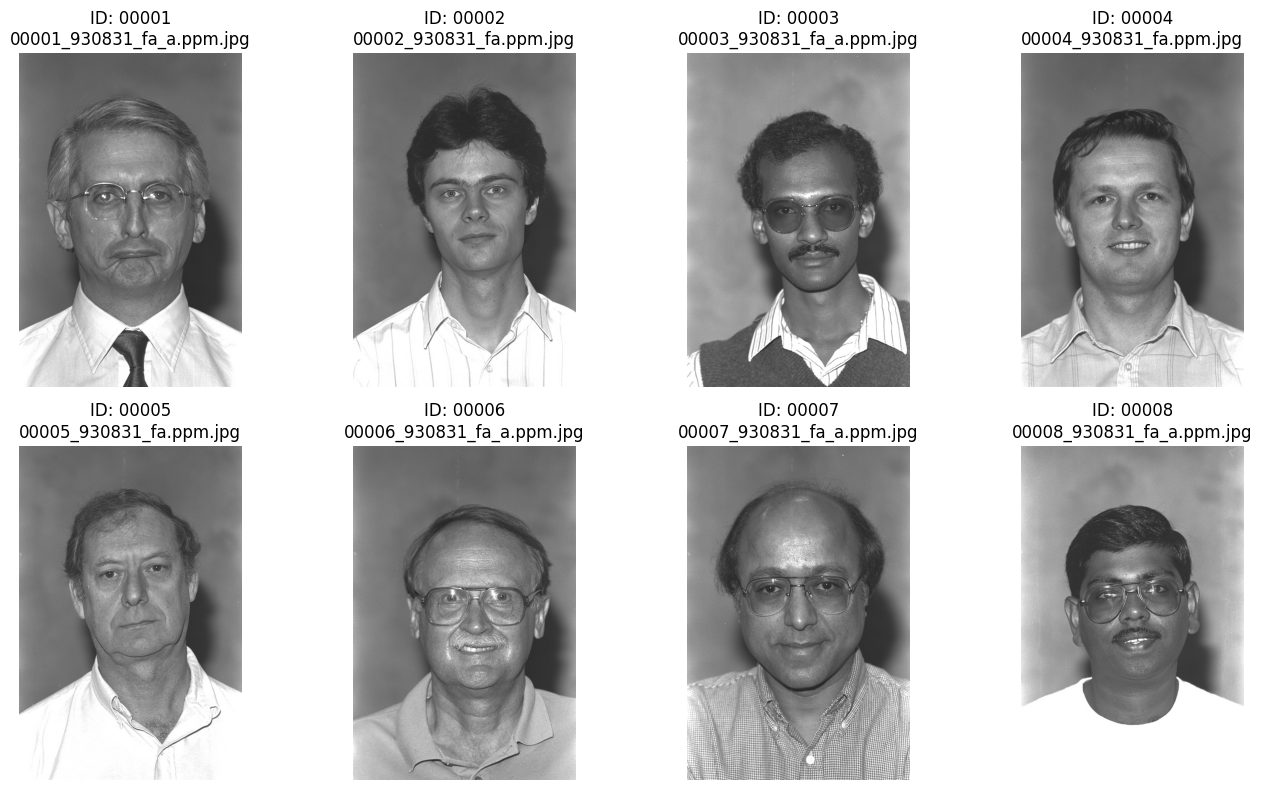

In [6]:
# ============================================================
# CELL 5 — VISUALIZE RAW FERETD FACES
# ============================================================

N_SHOW = 8

sample_records = feret_records[:N_SHOW]

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8)
)

axes = axes.ravel()

for ax, rec in zip(axes, sample_records):

    img_path = rec["images"][0]

    img_bgr = cv2.imread(str(img_path))

    if img_bgr is None:
        ax.set_title(f"{rec['identity']}\nFAILED LOAD")
        ax.axis("off")
        continue

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img_rgb)
    ax.set_title(
        f"ID: {rec['identity']}\n{img_path.name}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 6A — FIND DLIB 68-LANDMARK MODEL
# ============================================================

from pathlib import Path

matches = list(
    Path("/kaggle/input").rglob(
        "shape_predictor_68_face_landmarks.dat"
    )
)

print("=" * 80)
print("DLIB 68-LANDMARK MODEL SEARCH")
print("=" * 80)
print(f"Matches found: {len(matches)}")

for m in matches:
    print(m)

if not matches:
    raise FileNotFoundError(
        "Could not find shape_predictor_68_face_landmarks.dat "
        "inside /kaggle/input."
    )

PREDICTOR_PATH = str(matches[0])

print("\nUsing:")
print(PREDICTOR_PATH)

DLIB 68-LANDMARK MODEL SEARCH
Matches found: 1
/kaggle/input/datasets/mashfiqrizvee/dlibfile/shape_predictor_68_face_landmarks.dat

Using:
/kaggle/input/datasets/mashfiqrizvee/dlibfile/shape_predictor_68_face_landmarks.dat


In [9]:
# ============================================================
# CELL 6B — INITIALIZE DLIB
# ============================================================

import dlib

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)

print("✓ dlib frontal face detector ready")
print("✓ 68-landmark predictor ready")

✓ dlib frontal face detector ready
✓ 68-landmark predictor ready


In [13]:
# ============================================================
# CELL 7 — CORRECT FERETD fa/fb SELECTION
# ============================================================

import re

def get_feret_pose_images(images, pose_code):
    """
    Correctly detects FERET pose labels such as:
        _fa.
        _fa_
        _fb.
        _fb_
    regardless of extra suffixes like .ppm.jpg or _a.ppm.jpg
    """

    pose_code = pose_code.lower()

    pattern = re.compile(
        rf"_{pose_code}(?:_|\.|$)",
        flags=re.IGNORECASE
    )

    matches = []

    for p in images:
        name = p.name.lower()

        if pattern.search(name):
            matches.append(p)

    # Lexicographic sorting works correctly here because
    # filenames begin with identity + acquisition date.
    return sorted(matches)


feret_protocol_records = []

for rec in feret_records:

    fa_images = get_feret_pose_images(
        rec["images"], "fa"
    )

    fb_images = get_feret_pose_images(
        rec["images"], "fb"
    )

    if len(fa_images) == 0:
        continue

    enrollment_path = fa_images[0]

    second_path = (
        fb_images[0]
        if len(fb_images) > 0
        else None
    )

    feret_protocol_records.append({
        "identity": rec["identity"],
        "enrollment_path": enrollment_path,
        "second_path": second_path,
        "num_fa": len(fa_images),
        "num_fb": len(fb_images),
    })


n_fb = sum(
    rec["second_path"] is not None
    for rec in feret_protocol_records
)

print("=" * 90)
print("CORRECTED FERETD PROTOCOL")
print("=" * 90)

print(f"Identities with FA enrollment : {len(feret_protocol_records):,}")
print(f"Identities with FB query       : {n_fb:,}")

print("\nFirst 30 selections")
print("-" * 90)

for rec in feret_protocol_records[:30]:

    print(
        f"{rec['identity']} | "
        f"FA = {rec['enrollment_path'].name} | "
        f"FB = "
        f"{rec['second_path'].name if rec['second_path'] else 'NONE'}"
    )

CORRECTED FERETD PROTOCOL
Identities with FA enrollment : 994
Identities with FB query       : 993

First 30 selections
------------------------------------------------------------------------------------------
00001 | FA = 00001_930831_fa_a.ppm.jpg | FB = 00001_930831_fb_a.ppm.jpg
00002 | FA = 00002_930831_fa.ppm.jpg | FB = 00002_930831_fb.ppm.jpg
00003 | FA = 00003_930831_fa_a.ppm.jpg | FB = 00003_930831_fb_a.ppm.jpg
00004 | FA = 00004_930831_fa.ppm.jpg | FB = 00004_930831_fb.ppm.jpg
00005 | FA = 00005_930831_fa.ppm.jpg | FB = 00005_930831_fb.ppm.jpg
00006 | FA = 00006_930831_fa_a.ppm.jpg | FB = 00006_930831_fb_a.ppm.jpg
00007 | FA = 00007_930831_fa_a.ppm.jpg | FB = 00007_930831_fb_a.ppm.jpg
00008 | FA = 00008_930831_fa_a.ppm.jpg | FB = 00008_930831_fb_a.ppm.jpg
00009 | FA = 00009_930831_fa_a.ppm.jpg | FB = 00009_930831_fb_a.ppm.jpg
00010 | FA = 00010_930831_fa.ppm.jpg | FB = 00010_930831_fb.ppm.jpg
00012 | FA = 00012_930831_fa.ppm.jpg | FB = 00012_930831_fb.ppm.jpg
00013 | FA = 0001

In [14]:
# ============================================================
# CELL 8 — LANDMARK HELPER FUNCTIONS
# ============================================================

import cv2
import numpy as np


def shape_to_np(shape):
    points = np.zeros((68, 2), dtype=np.float32)

    for i in range(68):
        points[i] = [
            shape.part(i).x,
            shape.part(i).y
        ]

    return points


def detect_face_landmarks(image_bgr, upsample=1):

    gray = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )

    faces = detector(gray, upsample)

    if len(faces) == 0:
        return None, None

    # Select largest detected face
    face = max(
        faces,
        key=lambda r:
        (r.right() - r.left()) *
        (r.bottom() - r.top())
    )

    shape = predictor(gray, face)
    landmarks = shape_to_np(shape)

    return face, landmarks

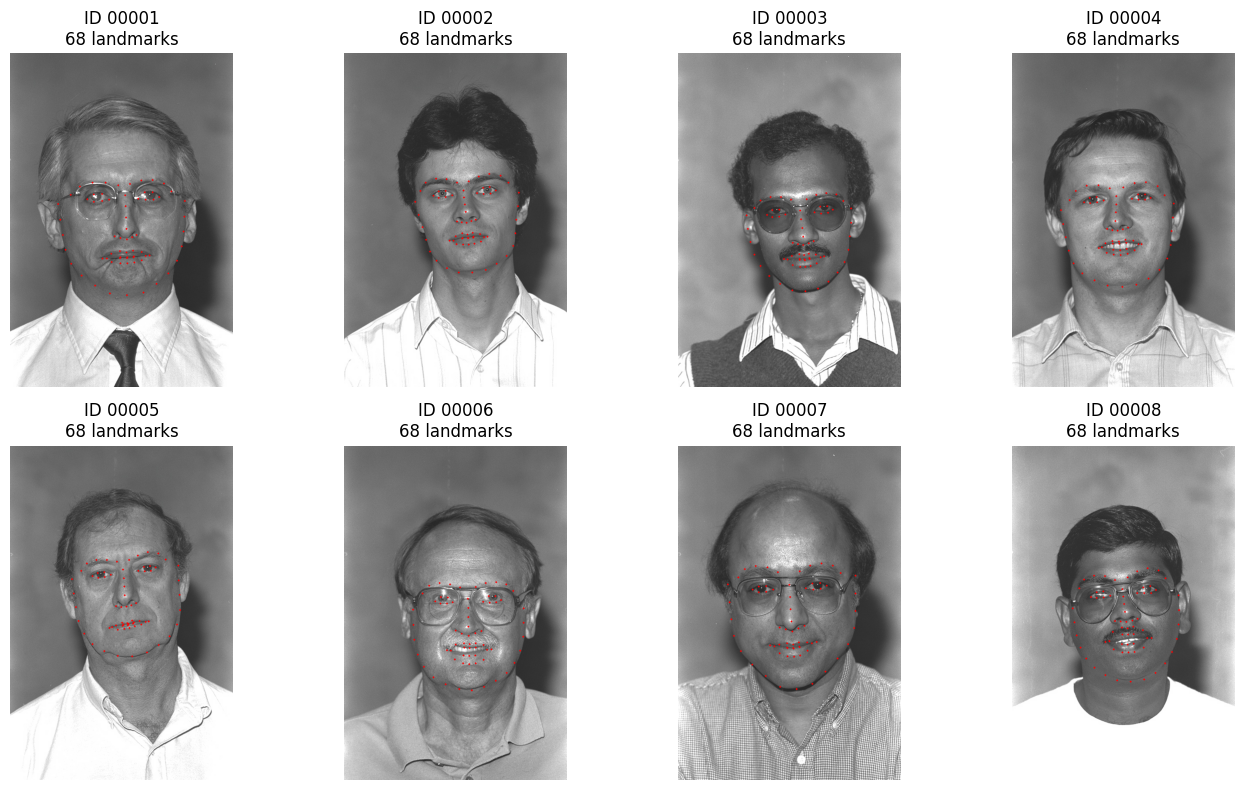

Displayed 8 successfully detected faces.


In [15]:
# ============================================================
# CELL 9 — VISUALIZE RAW LANDMARK DETECTION
# ============================================================

import matplotlib.pyplot as plt

N_SHOW = 8

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8)
)

axes = axes.ravel()

shown = 0

for rec in feret_protocol_records:

    if shown >= N_SHOW:
        break

    img = cv2.imread(
        str(rec["enrollment_path"])
    )

    if img is None:
        continue

    face, landmarks = detect_face_landmarks(img)

    if landmarks is None:
        continue

    vis = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Draw 68 landmark points
    for i, (x, y) in enumerate(landmarks):

        cv2.circle(
            vis,
            (int(x), int(y)),
            2,
            (255, 0, 0),
            -1
        )

    axes[shown].imshow(vis)
    axes[shown].set_title(
        f"ID {rec['identity']}\n68 landmarks"
    )
    axes[shown].axis("off")

    shown += 1

for i in range(shown, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {shown} successfully detected faces.")

In [16]:
# ============================================================
# CELL 10 — FACIAL GEOMETRY HELPERS
# ============================================================

ALIGN_SIZE = 256

# dlib 68-point landmark indexing:
# 36-41 = left eye
# 42-47 = right eye
# 30    = nose tip
# 48    = left mouth corner
# 54    = right mouth corner

LEFT_EYE_IDX = np.arange(36, 42)
RIGHT_EYE_IDX = np.arange(42, 48)

NOSE_TIP_IDX = 30
LEFT_MOUTH_IDX = 48
RIGHT_MOUTH_IDX = 54


def eye_center(landmarks, indices):
    return landmarks[indices].mean(axis=0)


def get_five_keypoints(landmarks):
    """
    Returns:
        left eye center
        right eye center
        nose tip
        left mouth corner
        right mouth corner
    """

    left_eye = eye_center(
        landmarks,
        LEFT_EYE_IDX
    )

    right_eye = eye_center(
        landmarks,
        RIGHT_EYE_IDX
    )

    nose = landmarks[NOSE_TIP_IDX]

    left_mouth = landmarks[LEFT_MOUTH_IDX]
    right_mouth = landmarks[RIGHT_MOUTH_IDX]

    return np.vstack([
        left_eye,
        right_eye,
        nose,
        left_mouth,
        right_mouth
    ]).astype(np.float32)


print("Alignment canvas:", ALIGN_SIZE, "x", ALIGN_SIZE)

Alignment canvas: 256 x 256


In [17]:
# ============================================================
# CELL 11 — PRELIMINARY CANONICAL TARGET
# ============================================================

PRELIM_TARGET_5 = np.array([
    [0.32 * ALIGN_SIZE, 0.36 * ALIGN_SIZE],  # left eye
    [0.68 * ALIGN_SIZE, 0.36 * ALIGN_SIZE],  # right eye
    [0.50 * ALIGN_SIZE, 0.56 * ALIGN_SIZE],  # nose
    [0.38 * ALIGN_SIZE, 0.74 * ALIGN_SIZE],  # left mouth
    [0.62 * ALIGN_SIZE, 0.74 * ALIGN_SIZE],  # right mouth
], dtype=np.float32)


print("=" * 70)
print("PRELIMINARY CANONICAL FACIAL LOCATIONS")
print("=" * 70)

names = [
    "Left eye",
    "Right eye",
    "Nose",
    "Left mouth",
    "Right mouth"
]

for name, point in zip(names, PRELIM_TARGET_5):
    print(
        f"{name:12s}: "
        f"x={point[0]:7.2f}, "
        f"y={point[1]:7.2f}"
    )

PRELIMINARY CANONICAL FACIAL LOCATIONS
Left eye    : x=  81.92, y=  92.16
Right eye   : x= 174.08, y=  92.16
Nose        : x= 128.00, y= 143.36
Left mouth  : x=  97.28, y= 189.44
Right mouth : x= 158.72, y= 189.44


In [18]:
# ============================================================
# CELL 12 — DETECT LANDMARKS FOR ALL ENROLLMENT IMAGES
# ============================================================

enrollment_landmark_records = []

failed_landmark_detection = []

print("=" * 80)
print("DETECTING LANDMARKS — FERETD ENROLLMENT IMAGES")
print("=" * 80)

for rec in tqdm(feret_protocol_records):

    identity = rec["identity"]
    img_path = rec["enrollment_path"]

    image = cv2.imread(
        str(img_path)
    )

    if image is None:

        failed_landmark_detection.append({
            "identity": identity,
            "path": str(img_path),
            "reason": "image_load_failed"
        })

        continue

    face, landmarks = detect_face_landmarks(
        image
    )

    if landmarks is None:

        failed_landmark_detection.append({
            "identity": identity,
            "path": str(img_path),
            "reason": "no_face_detected"
        })

        continue

    enrollment_landmark_records.append({
        "identity": identity,
        "path": img_path,
        "landmarks": landmarks,
        "image_shape": image.shape
    })


print()
print("=" * 80)
print("LANDMARK DETECTION SUMMARY")
print("=" * 80)

print(
    "Successful :",
    len(enrollment_landmark_records)
)

print(
    "Failed     :",
    len(failed_landmark_detection)
)

print(
    "Total      :",
    len(feret_protocol_records)
)

DETECTING LANDMARKS — FERETD ENROLLMENT IMAGES


  0%|          | 0/994 [00:00<?, ?it/s]


LANDMARK DETECTION SUMMARY
Successful : 993
Failed     : 1
Total      : 994


In [19]:
# ============================================================
# CELL 13 — PRELIMINARY LANDMARK NORMALIZATION
# ============================================================

def transform_points(points, matrix):
    """
    Apply a 2x3 affine matrix to Nx2 points.
    """

    points = np.asarray(
        points,
        dtype=np.float32
    )

    ones = np.ones(
        (len(points), 1),
        dtype=np.float32
    )

    homogeneous = np.hstack([
        points,
        ones
    ])

    transformed = (
        matrix @ homogeneous.T
    ).T

    return transformed.astype(np.float32)


normalized_landmark_sets = []
normalized_record_indices = []

for i, rec in enumerate(enrollment_landmark_records):

    landmarks = rec["landmarks"]

    source_5 = get_five_keypoints(
        landmarks
    )

    # Full affine transform estimated from five keypoints.
    M, inliers = cv2.estimateAffine2D(
        source_5,
        PRELIM_TARGET_5,
        method=cv2.LMEDS
    )

    if M is None:
        continue

    normalized_landmarks = transform_points(
        landmarks,
        M
    )

    normalized_landmark_sets.append(
        normalized_landmarks
    )

    normalized_record_indices.append(i)


normalized_landmark_sets = np.stack(
    normalized_landmark_sets,
    axis=0
)

print("=" * 80)
print("PRELIMINARY NORMALIZATION")
print("=" * 80)

print(
    "Normalized landmark sets:",
    normalized_landmark_sets.shape
)

PRELIMINARY NORMALIZATION
Normalized landmark sets: (993, 68, 2)


In [20]:
# ============================================================
# CELL 14 — BUILD CANONICAL 68-POINT FERETD FACE
# ============================================================

CANONICAL_68 = np.mean(
    normalized_landmark_sets,
    axis=0
).astype(np.float32)

print("=" * 80)
print("CANONICAL FERETD LANDMARK GEOMETRY")
print("=" * 80)

print("Shape:", CANONICAL_68.shape)

print("\nCanonical five-point geometry:")

canonical_5 = get_five_keypoints(
    CANONICAL_68
)

for name, point in zip(names, canonical_5):

    print(
        f"{name:12s}: "
        f"x={point[0]:7.2f}, "
        f"y={point[1]:7.2f}"
    )

CANONICAL FERETD LANDMARK GEOMETRY
Shape: (68, 2)

Canonical five-point geometry:
Left eye    : x=  87.32, y=  93.98
Right eye   : x= 166.23, y=  96.07
Nose        : x= 127.20, y= 139.99
Left mouth  : x=  92.89, y= 188.23
Right mouth : x= 162.54, y= 189.86


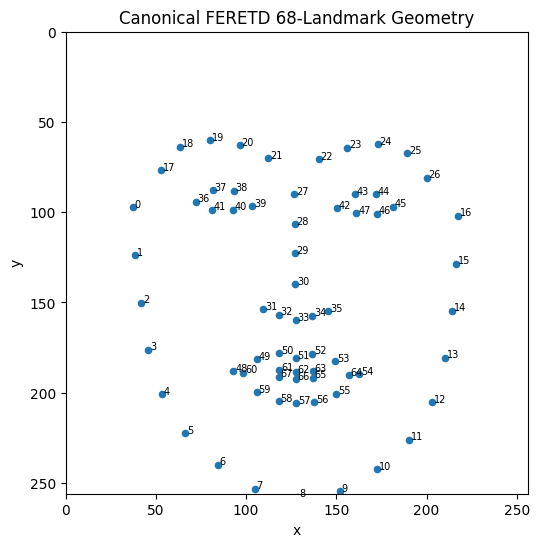

In [22]:
# ============================================================
# CELL 15 — VISUALIZE CANONICAL 68-LANDMARK FACE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.scatter(
    CANONICAL_68[:, 0],
    CANONICAL_68[:, 1],
    s=20
)

for i, (x, y) in enumerate(CANONICAL_68):
    ax.text(
        x + 1,
        y,
        str(i),
        fontsize=7
    )

ax.set_xlim(
    0,
    ALIGN_SIZE
)

ax.set_ylim(
    ALIGN_SIZE,
    0
)

ax.set_aspect("equal")

ax.set_title(
    "Canonical FERETD 68-Landmark Geometry"
)

ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [23]:
# ============================================================
# CELL 16 — FULL 68-LANDMARK AFFINE ALIGNMENT
# ============================================================

def align_face_to_canonical(
    image_bgr,
    landmarks,
    canonical_landmarks=CANONICAL_68,
    output_size=ALIGN_SIZE
):
    """
    Full affine alignment using all 68 landmark correspondences.
    """

    M, inliers = cv2.estimateAffine2D(
        landmarks.astype(np.float32),
        canonical_landmarks.astype(np.float32),
        method=cv2.LMEDS
    )

    if M is None:
        return None, None, None

    aligned = cv2.warpAffine(
        image_bgr,
        M,
        (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    transformed_landmarks = transform_points(
        landmarks,
        M
    )

    return (
        aligned,
        transformed_landmarks,
        M
    )

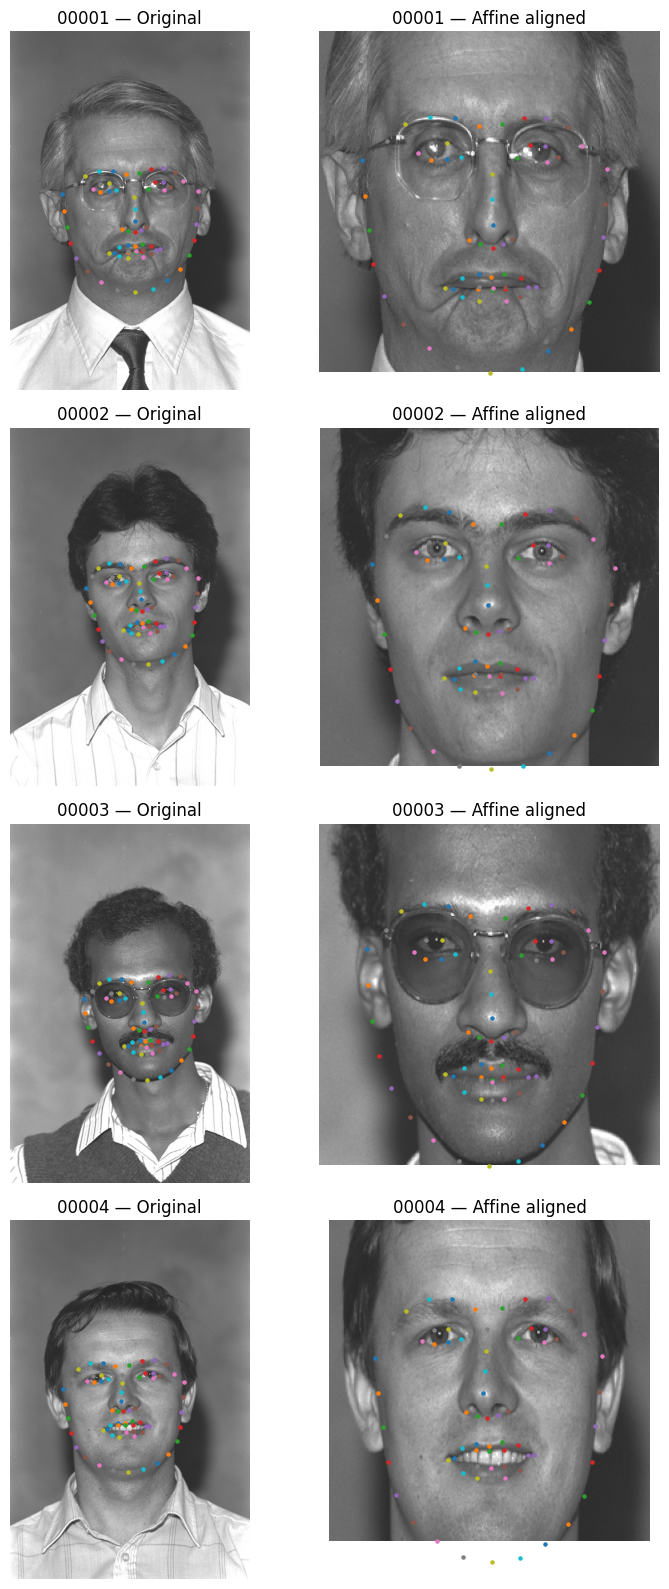

In [24]:
# ============================================================
# CELL 17 — ORIGINAL VS AFFINE-ALIGNED
# ============================================================

N_SHOW = 4

fig, axes = plt.subplots(
    N_SHOW,
    2,
    figsize=(8, 4 * N_SHOW)
)

shown = 0

for rec in enrollment_landmark_records:

    if shown >= N_SHOW:
        break

    image = cv2.imread(
        str(rec["path"])
    )

    landmarks = rec["landmarks"]

    aligned, aligned_landmarks, M = \
        align_face_to_canonical(
            image,
            landmarks
        )

    if aligned is None:
        continue

    # -------------------------
    # Original
    # -------------------------
    original_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    axes[shown, 0].imshow(
        original_rgb
    )

    for x, y in landmarks:
        axes[shown, 0].scatter(
            x,
            y,
            s=5
        )

    axes[shown, 0].set_title(
        f"{rec['identity']} — Original"
    )

    axes[shown, 0].axis("off")

    # -------------------------
    # Aligned
    # -------------------------
    aligned_rgb = cv2.cvtColor(
        aligned,
        cv2.COLOR_BGR2RGB
    )

    axes[shown, 1].imshow(
        aligned_rgb
    )

    for x, y in aligned_landmarks:
        axes[shown, 1].scatter(
            x,
            y,
            s=5
        )

    axes[shown, 1].set_title(
        f"{rec['identity']} — Affine aligned"
    )

    axes[shown, 1].axis("off")

    shown += 1

plt.tight_layout()
plt.show()

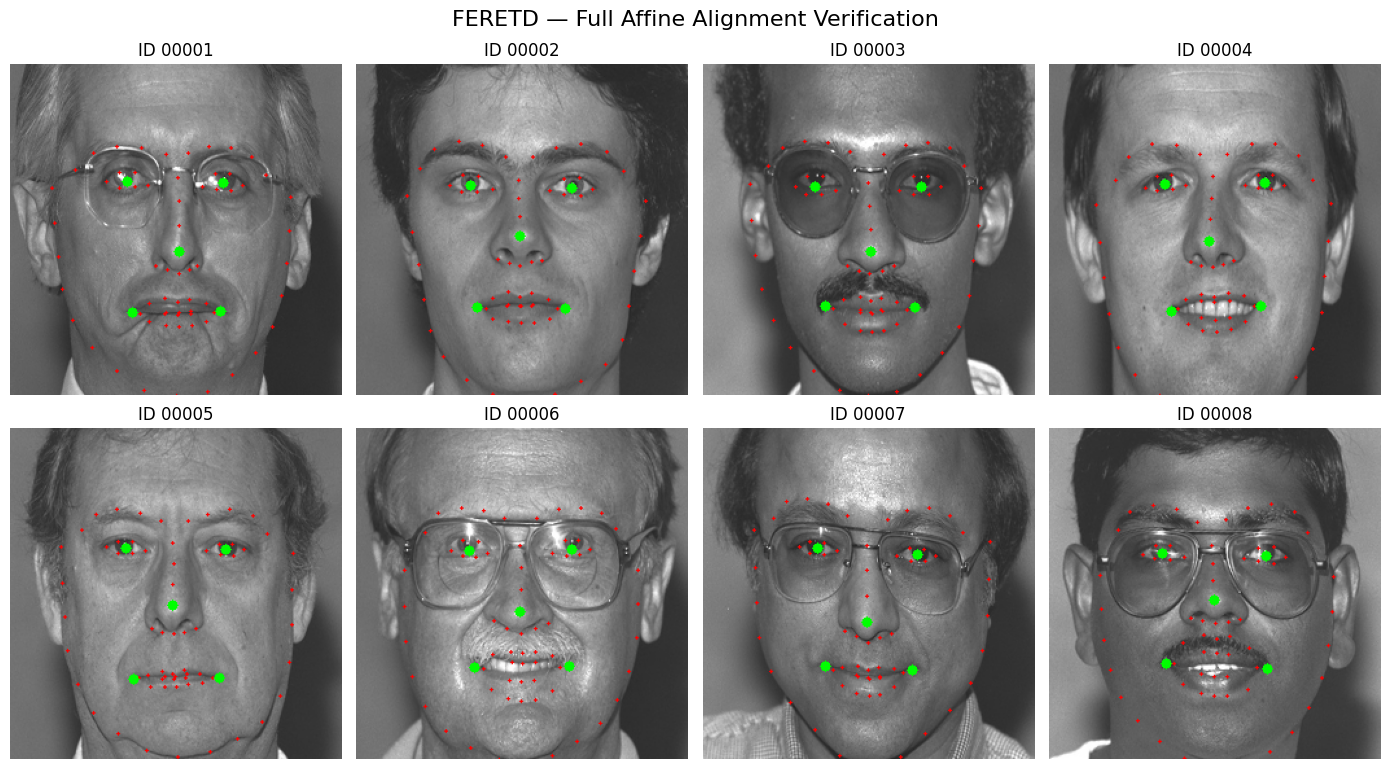

In [25]:
# ============================================================
# CELL 18 — MULTI-FACE ALIGNMENT VERIFICATION
# ============================================================

N_SHOW = 8

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

axes = axes.ravel()

shown = 0

for rec in enrollment_landmark_records:

    if shown >= N_SHOW:
        break

    image = cv2.imread(
        str(rec["path"])
    )

    landmarks = rec["landmarks"]

    aligned, aligned_landmarks, M = \
        align_face_to_canonical(
            image,
            landmarks
        )

    if aligned is None:
        continue

    vis = cv2.cvtColor(
        aligned,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # All 68 landmarks
    # --------------------------------------------------------
    for x, y in aligned_landmarks:

        cv2.circle(
            vis,
            (int(round(x)), int(round(y))),
            1,
            (255, 0, 0),
            -1
        )

    # --------------------------------------------------------
    # Five important anatomical locations
    # --------------------------------------------------------
    key5 = get_five_keypoints(
        aligned_landmarks
    )

    for x, y in key5:

        cv2.circle(
            vis,
            (int(round(x)), int(round(y))),
            4,
            (0, 255, 0),
            -1
        )

    axes[shown].imshow(vis)

    axes[shown].set_title(
        f"ID {rec['identity']}"
    )

    axes[shown].axis("off")

    shown += 1


for i in range(shown, len(axes)):
    axes[i].axis("off")


plt.suptitle(
    "FERETD — Full Affine Alignment Verification",
    fontsize=16
)

plt.tight_layout()
plt.show()

  0%|          | 0/993 [00:00<?, ?it/s]

Aligned landmark matrix: (993, 68, 2)


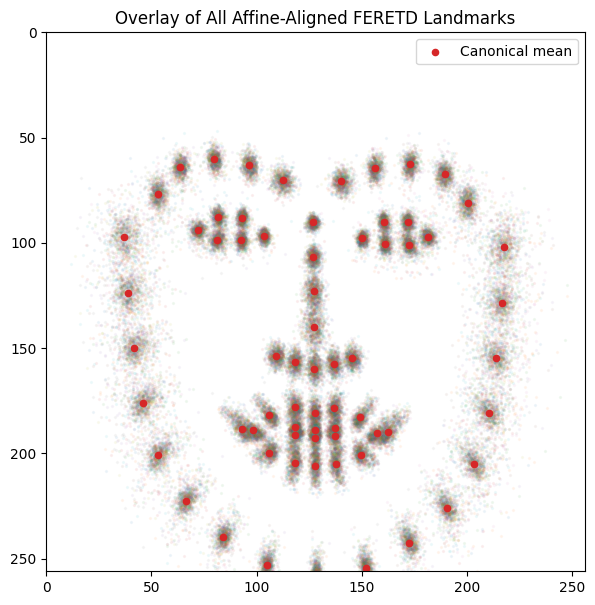

In [26]:
# ============================================================
# CELL 19 — OVERLAY ALIGNED LANDMARK CONFIGURATIONS
# ============================================================

all_aligned_landmarks = []

alignment_records = []

for rec in tqdm(enrollment_landmark_records):

    image = cv2.imread(
        str(rec["path"])
    )

    if image is None:
        continue

    aligned, transformed, M = \
        align_face_to_canonical(
            image,
            rec["landmarks"]
        )

    if aligned is None:
        continue

    all_aligned_landmarks.append(
        transformed
    )

    alignment_records.append({
        "identity": rec["identity"],
        "path": rec["path"],
        "matrix": M
    })


all_aligned_landmarks = np.stack(
    all_aligned_landmarks
)

print(
    "Aligned landmark matrix:",
    all_aligned_landmarks.shape
)


plt.figure(
    figsize=(7, 7)
)

# Plot all transformed configurations lightly
for lm in all_aligned_landmarks:

    plt.scatter(
        lm[:, 0],
        lm[:, 1],
        s=2,
        alpha=0.05
    )

# Canonical geometry on top
plt.scatter(
    CANONICAL_68[:, 0],
    CANONICAL_68[:, 1],
    s=20,
    label="Canonical mean"
)

plt.xlim(
    0,
    ALIGN_SIZE
)

plt.ylim(
    ALIGN_SIZE,
    0
)

plt.gca().set_aspect("equal")

plt.title(
    "Overlay of All Affine-Aligned FERETD Landmarks"
)

plt.legend()

plt.show()

In [27]:
# ============================================================
# CELL 20 — QUANTITATIVE ALIGNMENT CONSISTENCY
# ============================================================

all_keypoints = []

for lm in all_aligned_landmarks:

    keypoints = get_five_keypoints(
        lm
    )

    all_keypoints.append(
        keypoints
    )


all_keypoints = np.stack(
    all_keypoints
)

# Shape:
# N_faces x 5_keypoints x 2_coordinates

rows = []

for i, name in enumerate(names):

    x_values = all_keypoints[:, i, 0]
    y_values = all_keypoints[:, i, 1]

    rows.append({
        "Feature": name,
        "Mean X": np.mean(x_values),
        "Std X": np.std(x_values),
        "Mean Y": np.mean(y_values),
        "Std Y": np.std(y_values),
    })


alignment_df = pd.DataFrame(rows)

print("=" * 80)
print("AFFINE ALIGNMENT CONSISTENCY")
print("=" * 80)

display(
    alignment_df.round(3)
)

AFFINE ALIGNMENT CONSISTENCY


,Feature,Mean X,Std X,Mean Y,Std Y
0,Left eye,87.416000,1.678,94.247002,2.418
1,Right eye,166.167007,1.695,96.407997,2.705
2,Nose,127.100998,2.799,140.072006,5.992
3,Left mouth,92.778999,3.509,188.149002,4.005
4,Right mouth,162.673996,3.285,189.873993,4.006


In [51]:
# ============================================================
# REVISED CELL 21 — TIGHTER PAPER-STYLE ELLIPTICAL MASK
# ============================================================

x_min = CANONICAL_68[:, 0].min()
x_max = CANONICAL_68[:, 0].max()

y_min = CANONICAL_68[:, 1].min()
y_max = CANONICAL_68[:, 1].max()

face_center_x = (x_min + x_max) / 2.0
face_center_y = (y_min + y_max) / 2.0

face_width = x_max - x_min
face_height = y_max - y_min

# Slightly narrower:
# suppresses ears and lateral hair more strongly
horizontal_radius = face_width * 0.48

# Slightly shorter:
# suppresses excessive forehead and lower chin
vertical_radius = face_height * 0.50

# Move slightly upward so the lower chin is removed
# while eyes/nose/mouth remain safely inside.
ELLIPSE_CENTER = (
    int(round(face_center_x)),
    int(round(face_center_y - 7))
)

ELLIPSE_AXES = (
    int(round(horizontal_radius)),
    int(round(vertical_radius))
)

print("=" * 80)
print("REVISED CANONICAL ELLIPTICAL MASK")
print("=" * 80)

print("Center :", ELLIPSE_CENTER)
print("Axes   :", ELLIPSE_AXES)

REVISED CANONICAL ELLIPTICAL MASK
Center : (127, 152)
Axes   : (87, 99)


Mask shape : (256, 256)
Mask values: [  0 255]


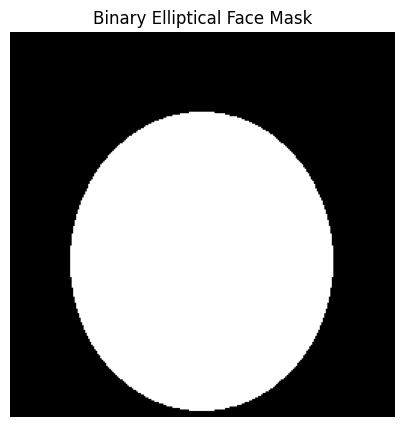

In [52]:
# ============================================================
# CELL 22 — CREATE BINARY ELLIPTICAL MASK
# ============================================================

def create_elliptical_mask(
    size=ALIGN_SIZE,
    center=ELLIPSE_CENTER,
    axes=ELLIPSE_AXES
):

    mask = np.zeros(
        (size, size),
        dtype=np.uint8
    )

    cv2.ellipse(
        mask,
        center=center,
        axes=axes,
        angle=0,
        startAngle=0,
        endAngle=360,
        color=255,
        thickness=-1
    )

    return mask


ELLIPTICAL_MASK = create_elliptical_mask()

print("Mask shape :", ELLIPTICAL_MASK.shape)
print("Mask values:", np.unique(ELLIPTICAL_MASK))

plt.figure(figsize=(5, 5))

plt.imshow(
    ELLIPTICAL_MASK,
    cmap="gray"
)

plt.title("Binary Elliptical Face Mask")
plt.axis("off")

plt.show()

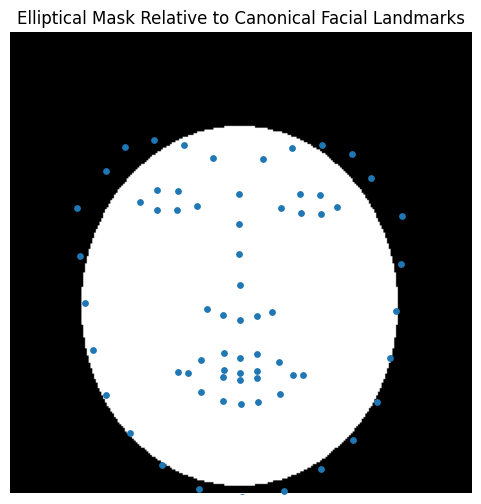

In [53]:
# ============================================================
# CELL 23 — MASK + CANONICAL LANDMARK CHECK
# ============================================================

plt.figure(figsize=(6, 6))

plt.imshow(
    ELLIPTICAL_MASK,
    cmap="gray"
)

plt.scatter(
    CANONICAL_68[:, 0],
    CANONICAL_68[:, 1],
    s=15
)

plt.xlim(0, ALIGN_SIZE)
plt.ylim(ALIGN_SIZE, 0)

plt.title(
    "Elliptical Mask Relative to Canonical Facial Landmarks"
)

plt.axis("off")

plt.show()

In [54]:
# ============================================================
# CELL 24 — GRAYSCALE + ELLIPTICAL MASK
# ============================================================

def apply_paper_mask(aligned_bgr):

    # --------------------------------------------
    # Convert to grayscale
    # --------------------------------------------
    gray = cv2.cvtColor(
        aligned_bgr,
        cv2.COLOR_BGR2GRAY
    )

    # --------------------------------------------
    # Logical AND with binary ellipse
    # --------------------------------------------
    masked = cv2.bitwise_and(
        gray,
        gray,
        mask=ELLIPTICAL_MASK
    )

    return gray, masked

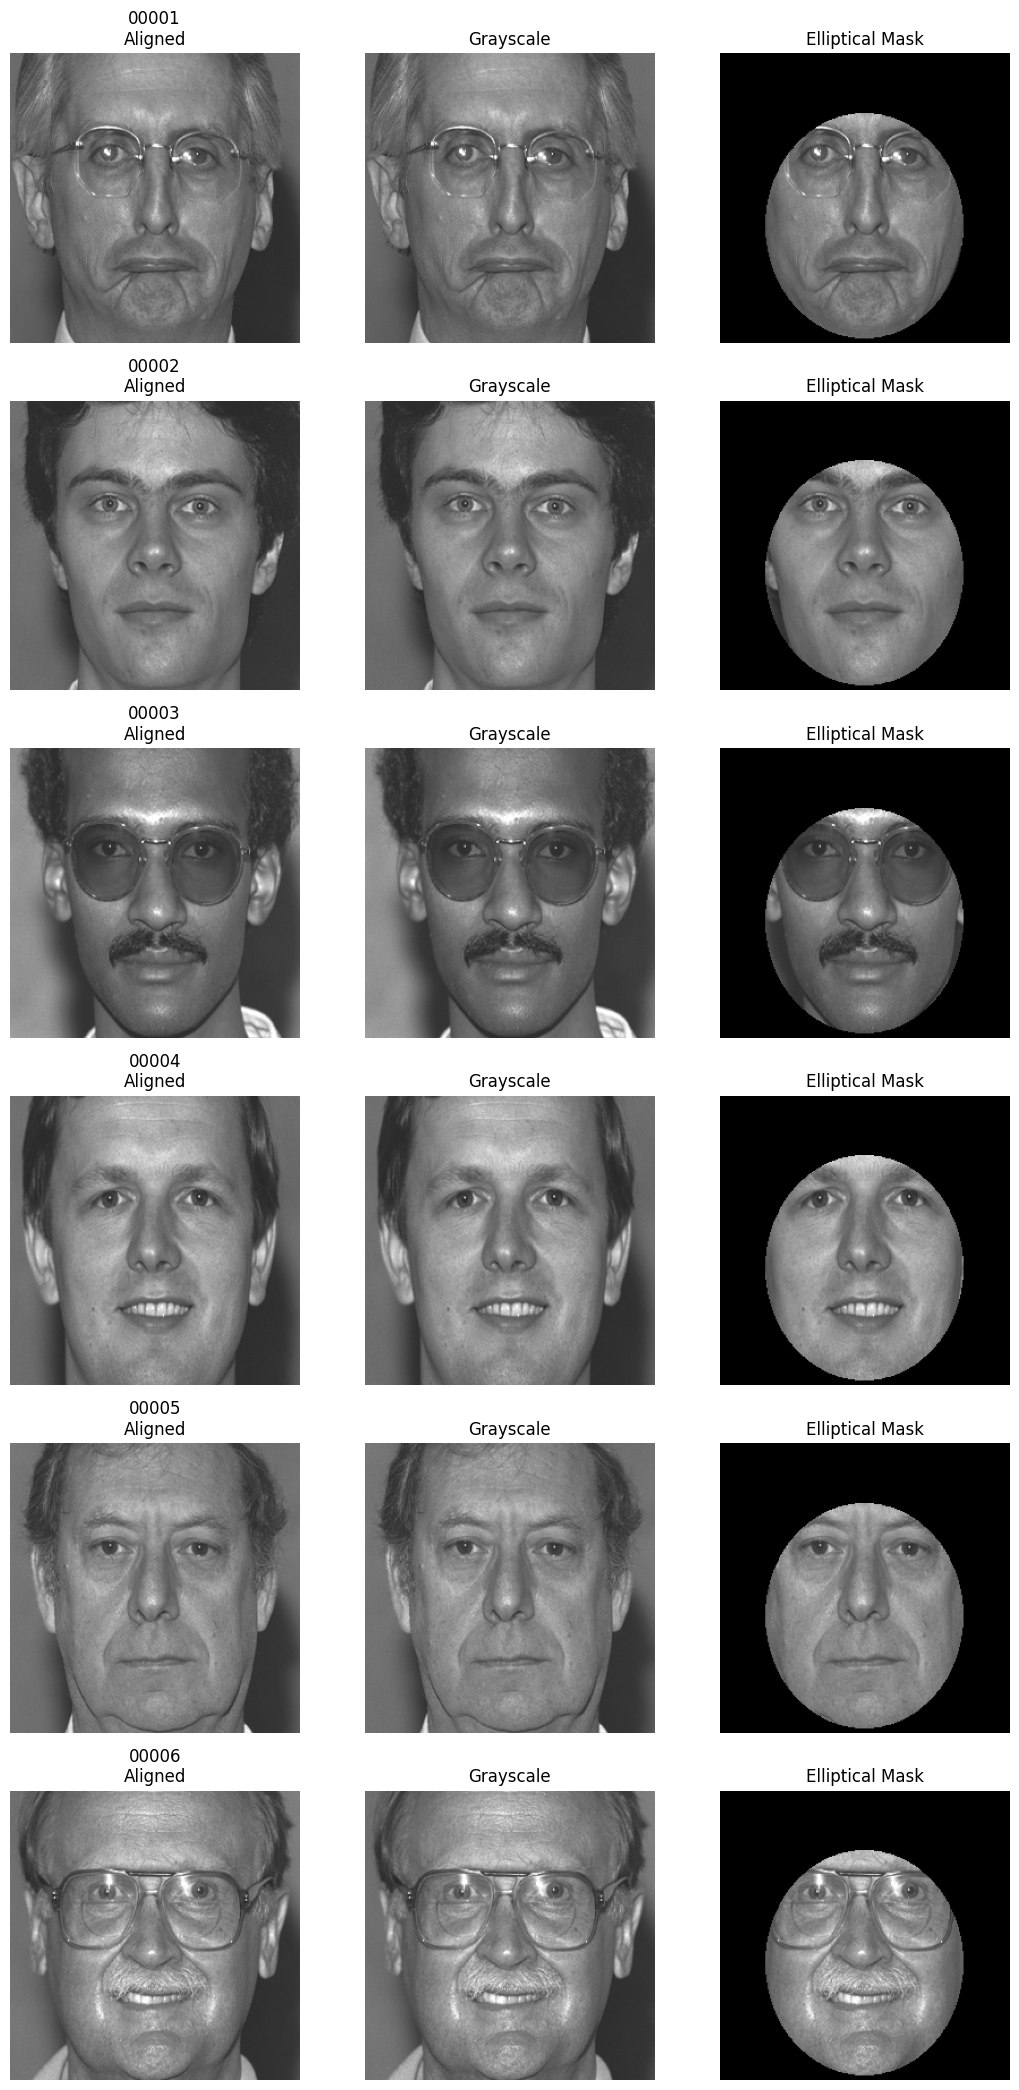

In [55]:
# ============================================================
# CELL 25 — VISUALIZE MASKING PIPELINE
# ============================================================

N_SHOW = 6

fig, axes = plt.subplots(
    N_SHOW,
    3,
    figsize=(11, 3.5 * N_SHOW)
)

shown = 0

for rec in enrollment_landmark_records:

    if shown >= N_SHOW:
        break

    image = cv2.imread(
        str(rec["path"])
    )

    if image is None:
        continue

    aligned, aligned_landmarks, M = \
        align_face_to_canonical(
            image,
            rec["landmarks"]
        )

    if aligned is None:
        continue

    gray, masked = apply_paper_mask(
        aligned
    )

    # --------------------------------------------
    # Column 1 — aligned
    # --------------------------------------------
    axes[shown, 0].imshow(
        cv2.cvtColor(
            aligned,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[shown, 0].set_title(
        f"{rec['identity']}\nAligned"
    )

    axes[shown, 0].axis("off")

    # --------------------------------------------
    # Column 2 — grayscale
    # --------------------------------------------
    axes[shown, 1].imshow(
        gray,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[shown, 1].set_title(
        "Grayscale"
    )

    axes[shown, 1].axis("off")

    # --------------------------------------------
    # Column 3 — masked
    # --------------------------------------------
    axes[shown, 2].imshow(
        masked,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[shown, 2].set_title(
        "Elliptical Mask"
    )

    axes[shown, 2].axis("off")

    shown += 1

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# REVISED CELL 26 — PAPER-STYLE HISTOGRAM EQUALIZATION
# ============================================================

def paper_histogram_equalization(masked_gray):

    equalized = cv2.equalizeHist(
        masked_gray
    )

    # Ensure background remains exactly zero.
    equalized[
        ELLIPTICAL_MASK == 0
    ] = 0

    return equalized

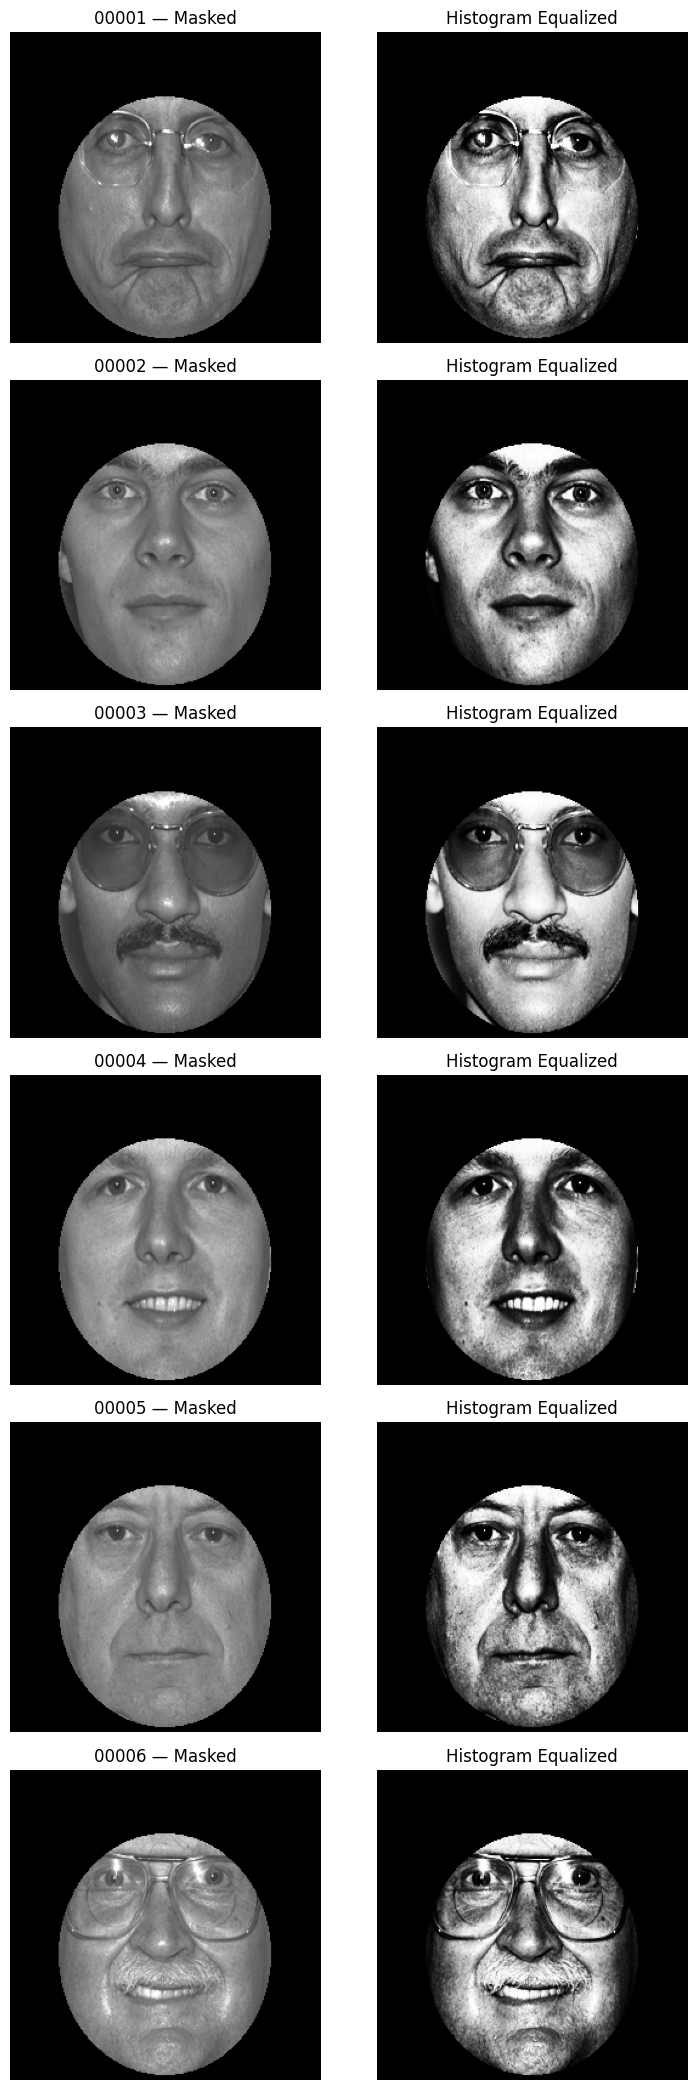

In [57]:
# ============================================================
# CELL 27 — HISTOGRAM EQUALIZATION VISUALIZATION
# ============================================================

N_SHOW = 6

fig, axes = plt.subplots(
    N_SHOW,
    2,
    figsize=(8, 3.5 * N_SHOW)
)

shown = 0

for rec in enrollment_landmark_records:

    if shown >= N_SHOW:
        break

    image = cv2.imread(
        str(rec["path"])
    )

    if image is None:
        continue

    aligned, _, _ = align_face_to_canonical(
        image,
        rec["landmarks"]
    )

    if aligned is None:
        continue

    gray, masked = apply_paper_mask(
        aligned
    )

    equalized = masked_histogram_equalization(
        masked
    )

    axes[shown, 0].imshow(
        masked,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[shown, 0].set_title(
        f"{rec['identity']} — Masked"
    )

    axes[shown, 0].axis("off")

    axes[shown, 1].imshow(
        equalized,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[shown, 1].set_title(
        "Histogram Equalized"
    )

    axes[shown, 1].axis("off")

    shown += 1


plt.tight_layout()
plt.show()

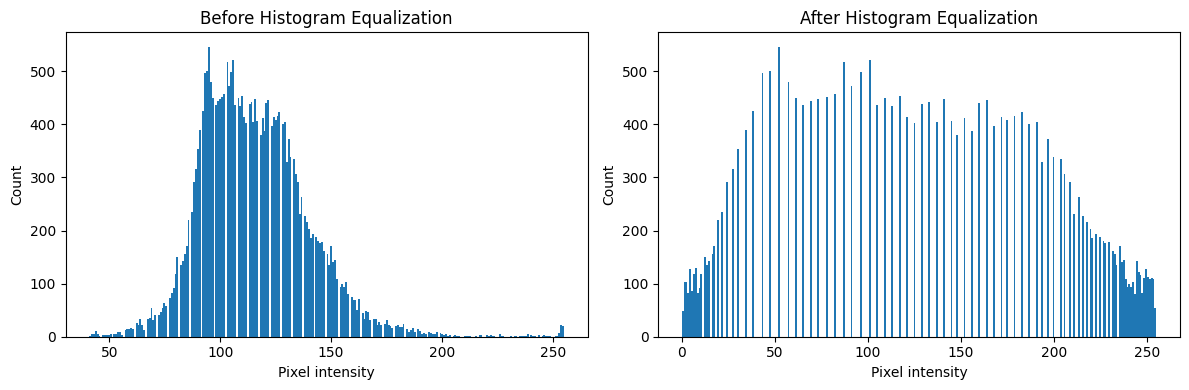

In [58]:
# ============================================================
# CELL 28 — INTENSITY DISTRIBUTION CHECK
# ============================================================

example_rec = enrollment_landmark_records[0]

image = cv2.imread(
    str(example_rec["path"])
)

aligned, _, _ = align_face_to_canonical(
    image,
    example_rec["landmarks"]
)

gray, masked = apply_paper_mask(
    aligned
)

equalized = masked_histogram_equalization(
    masked
)

valid = ELLIPTICAL_MASK > 0


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    masked[valid].ravel(),
    bins=256
)

axes[0].set_title(
    "Before Histogram Equalization"
)

axes[0].set_xlabel(
    "Pixel intensity"
)

axes[0].set_ylabel(
    "Count"
)


axes[1].hist(
    equalized[valid].ravel(),
    bins=256
)

axes[1].set_title(
    "After Histogram Equalization"
)

axes[1].set_xlabel(
    "Pixel intensity"
)

axes[1].set_ylabel(
    "Count"
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# CELL 29 — RESIZE TO 70 x 70
# ============================================================

def resize_to_paper_template(
    equalized_image
):

    resized = cv2.resize(
        equalized_image,
        (TEMPLATE_W, TEMPLATE_H),
        interpolation=cv2.INTER_AREA
    )

    return resized


example_70 = resize_to_paper_template(
    equalized
)

print("Image shape:", example_70.shape)

assert example_70.shape == (70, 70)

print(
    "Feature count:",
    example_70.size
)

assert example_70.size == 4900

Image shape: (70, 70)
Feature count: 4900


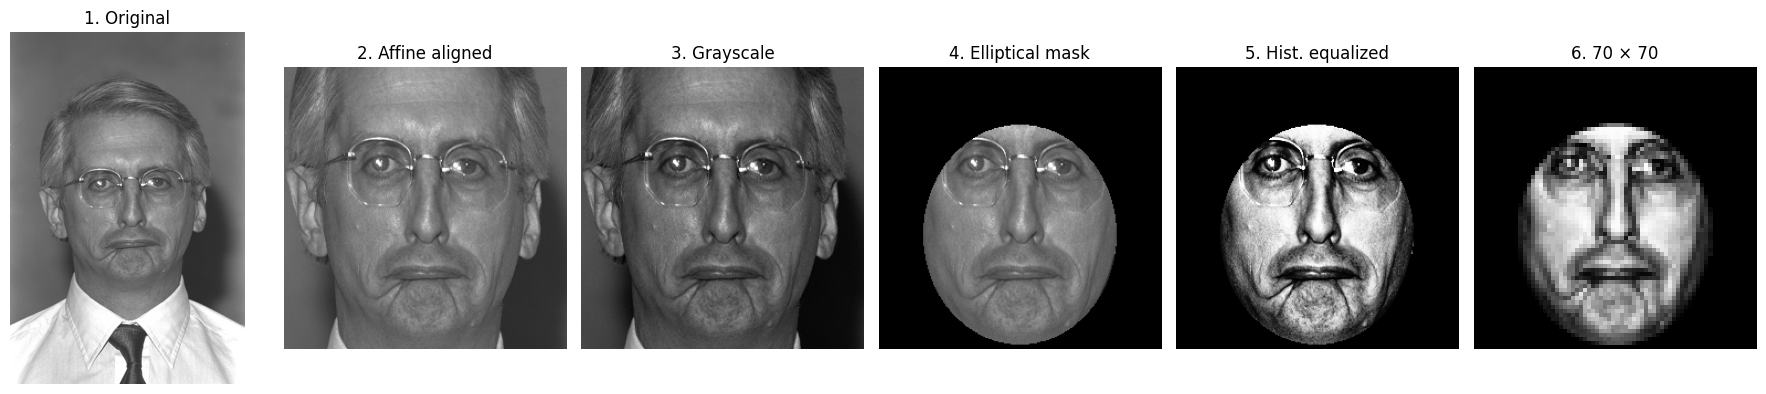

In [60]:
# ============================================================
# CELL 30 — COMPLETE PREPROCESSING VISUALIZATION
# ============================================================

rec = enrollment_landmark_records[0]

original = cv2.imread(
    str(rec["path"])
)

aligned, aligned_landmarks, _ = \
    align_face_to_canonical(
        original,
        rec["landmarks"]
    )

gray, masked = apply_paper_mask(
    aligned
)

equalized = masked_histogram_equalization(
    masked
)

resized_70 = resize_to_paper_template(
    equalized
)


fig, axes = plt.subplots(
    1,
    6,
    figsize=(18, 4)
)

# 1
axes[0].imshow(
    cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )
)

axes[0].set_title(
    "1. Original"
)
axes[0].axis("off")


# 2
axes[1].imshow(
    cv2.cvtColor(
        aligned,
        cv2.COLOR_BGR2RGB
    )
)

axes[1].set_title(
    "2. Affine aligned"
)
axes[1].axis("off")


# 3
axes[2].imshow(
    gray,
    cmap="gray"
)

axes[2].set_title(
    "3. Grayscale"
)
axes[2].axis("off")


# 4
axes[3].imshow(
    masked,
    cmap="gray"
)

axes[3].set_title(
    "4. Elliptical mask"
)
axes[3].axis("off")


# 5
axes[4].imshow(
    equalized,
    cmap="gray"
)

axes[4].set_title(
    "5. Hist. equalized"
)
axes[4].axis("off")


# 6
axes[5].imshow(
    resized_70,
    cmap="gray"
)

axes[5].set_title(
    "6. 70 × 70"
)
axes[5].axis("off")


plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# CELL 31 — 4900-D INTENSITY FEATURE VECTOR
# ============================================================

feature_vector = resized_70.flatten()

print("=" * 80)
print("PAPER-STYLE PRE-BINARY FEATURE VECTOR")
print("=" * 80)

print("Image shape     :", resized_70.shape)
print("Vector shape    :", feature_vector.shape)
print("Feature count   :", len(feature_vector))
print("dtype           :", feature_vector.dtype)

print(
    "Minimum value  :",
    feature_vector.min()
)

print(
    "Maximum value  :",
    feature_vector.max()
)

assert feature_vector.shape == (4900,)

PAPER-STYLE PRE-BINARY FEATURE VECTOR
Image shape     : (70, 70)
Vector shape    : (4900,)
Feature count   : 4900
dtype           : uint8
Minimum value  : 0
Maximum value  : 254


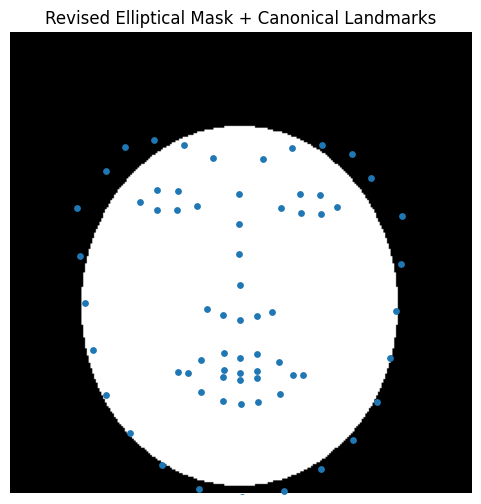

In [62]:
# ============================================================
# RECREATE REVISED MASK
# ============================================================

ELLIPTICAL_MASK = np.zeros(
    (ALIGN_SIZE, ALIGN_SIZE),
    dtype=np.uint8
)

cv2.ellipse(
    ELLIPTICAL_MASK,
    ELLIPSE_CENTER,
    ELLIPSE_AXES,
    0,
    0,
    360,
    255,
    -1
)

plt.figure(figsize=(6, 6))

plt.imshow(
    ELLIPTICAL_MASK,
    cmap="gray"
)

plt.scatter(
    CANONICAL_68[:, 0],
    CANONICAL_68[:, 1],
    s=15
)

plt.xlim(0, ALIGN_SIZE)
plt.ylim(ALIGN_SIZE, 0)

plt.title(
    "Revised Elliptical Mask + Canonical Landmarks"
)

plt.axis("off")

plt.show()

In [63]:
# ============================================================
# CELL 32 — COMPLETE PRE-BINARY PREPROCESSING FUNCTION
# ============================================================

def preprocess_to_4900(
    image_path,
    return_intermediates=False
):
    """
    Paper-style preprocessing:

        input image
          -> face detection
          -> 68 landmarks
          -> affine alignment
          -> grayscale
          -> elliptical mask
          -> histogram equalization
          -> 70 x 70 resize
          -> 4900-D intensity vector

    IMPORTANT:
    This function does NOT perform binary quantization yet.
    """

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        return None

    # ---------------------------------------------
    # Face + landmarks
    # ---------------------------------------------
    face, landmarks = detect_face_landmarks(
        image
    )

    if landmarks is None:
        return None

    # ---------------------------------------------
    # Canonical affine alignment
    # ---------------------------------------------
    aligned, aligned_landmarks, M = \
        align_face_to_canonical(
            image,
            landmarks
        )

    if aligned is None:
        return None

    # ---------------------------------------------
    # Grayscale + elliptical mask
    # ---------------------------------------------
    gray, masked = apply_paper_mask(
        aligned
    )

    # ---------------------------------------------
    # Histogram equalization
    # ---------------------------------------------
    equalized = paper_histogram_equalization(
        masked
    )

    # ---------------------------------------------
    # 70 x 70
    # ---------------------------------------------
    resized = resize_to_paper_template(
        equalized
    )

    # ---------------------------------------------
    # Flatten
    # ---------------------------------------------
    vector = resized.reshape(-1).astype(
        np.float32
    )

    assert vector.shape == (4900,)

    if return_intermediates:

        return {
            "vector": vector,
            "original": image,
            "landmarks": landmarks,
            "aligned": aligned,
            "aligned_landmarks": aligned_landmarks,
            "gray": gray,
            "masked": masked,
            "equalized": equalized,
            "resized": resized,
            "matrix": M
        }

    return vector


print("✓ Complete preprocessing function defined")

✓ Complete preprocessing function defined


In [64]:
# ============================================================
# CELL 33 — PROCESS ALL FERETD ENROLLMENT IMAGES
# ============================================================

enrollment_vectors = []
enrollment_metadata = []
enrollment_failures = []

print("=" * 80)
print("PREPROCESSING FERETD ENROLLMENT IMAGES")
print("=" * 80)

for rec in tqdm(feret_protocol_records):

    identity = rec["identity"]
    path = rec["enrollment_path"]

    vector = preprocess_to_4900(
        path
    )

    if vector is None:

        enrollment_failures.append({
            "identity": identity,
            "path": str(path)
        })

        continue

    enrollment_vectors.append(
        vector
    )

    enrollment_metadata.append({
        "identity": identity,
        "image_path": str(path),
        "filename": path.name,
        "role": "enrollment"
    })


ENROLLMENT_FEATURES = np.stack(
    enrollment_vectors
).astype(np.float32)

enrollment_metadata_df = pd.DataFrame(
    enrollment_metadata
)


print("\n" + "=" * 80)
print("ENROLLMENT PREPROCESSING SUMMARY")
print("=" * 80)

print(
    "Successful templates :",
    ENROLLMENT_FEATURES.shape[0]
)

print(
    "Failed templates     :",
    len(enrollment_failures)
)

print(
    "Feature matrix shape :",
    ENROLLMENT_FEATURES.shape
)

print(
    "Feature dtype        :",
    ENROLLMENT_FEATURES.dtype
)

assert ENROLLMENT_FEATURES.shape[1] == 4900

PREPROCESSING FERETD ENROLLMENT IMAGES


  0%|          | 0/994 [00:00<?, ?it/s]


ENROLLMENT PREPROCESSING SUMMARY
Successful templates : 993
Failed templates     : 1
Feature matrix shape : (993, 4900)
Feature dtype        : float32


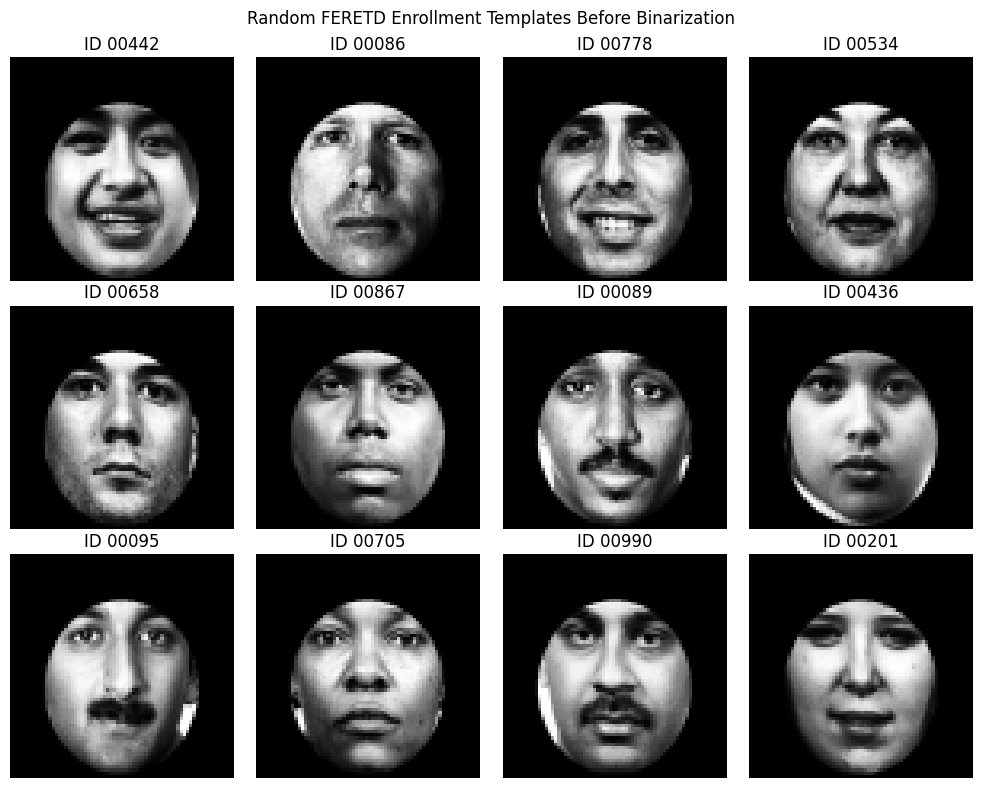

In [65]:
# ============================================================
# CELL 34 — VISUALIZE RANDOM PREPROCESSED ENROLLMENT FACES
# ============================================================

rng = np.random.default_rng(SEED)

n_show = min(
    12,
    len(ENROLLMENT_FEATURES)
)

indices = rng.choice(
    len(ENROLLMENT_FEATURES),
    size=n_show,
    replace=False
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(10, 8)
)

axes = axes.ravel()

for ax, idx in zip(axes, indices):

    image70 = ENROLLMENT_FEATURES[idx].reshape(
        70, 70
    )

    identity = enrollment_metadata_df.iloc[idx][
        "identity"
    ]

    ax.imshow(
        image70,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f"ID {identity}"
    )

    ax.axis("off")

plt.suptitle(
    "Random FERETD Enrollment Templates Before Binarization"
)

plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# CELL 35 — CALCULATE 4900-D POPULATION MEAN VECTOR
# ============================================================

MEAN_VECTOR = ENROLLMENT_FEATURES.mean(
    axis=0
).astype(np.float32)


print("=" * 80)
print("POPULATION MEAN VECTOR")
print("=" * 80)

print(
    "Samples used      :",
    ENROLLMENT_FEATURES.shape[0]
)

print(
    "Mean vector shape :",
    MEAN_VECTOR.shape
)

print(
    "Minimum mean      :",
    f"{MEAN_VECTOR.min():.3f}"
)

print(
    "Maximum mean      :",
    f"{MEAN_VECTOR.max():.3f}"
)

print(
    "Average mean      :",
    f"{MEAN_VECTOR.mean():.3f}"
)

assert MEAN_VECTOR.shape == (4900,)

POPULATION MEAN VECTOR
Samples used      : 993
Mean vector shape : (4900,)
Minimum mean      : 0.000
Maximum mean      : 231.509
Average mean      : 53.957


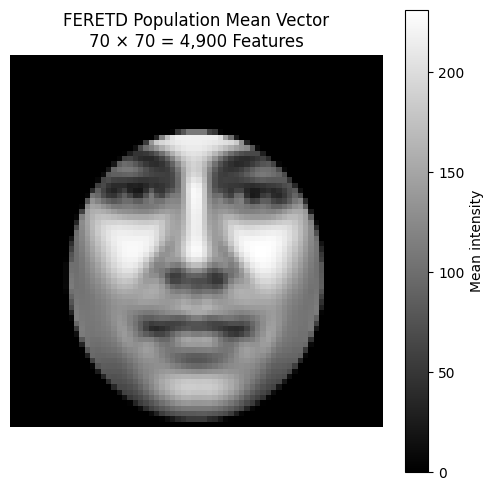

In [67]:
# ============================================================
# CELL 36 — VISUALIZE POPULATION MEAN VECTOR
# ============================================================

mean_face = MEAN_VECTOR.reshape(
    70, 70
)

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    mean_face,
    cmap="gray"
)

plt.title(
    "FERETD Population Mean Vector\n70 × 70 = 4,900 Features"
)

plt.colorbar(
    label="Mean intensity"
)

plt.axis("off")

plt.show()

In [68]:
# ============================================================
# CELL 37 — BINARY QUANTIZATION
# ============================================================

def binarize_with_population_mean(
    feature_vector,
    mean_vector=MEAN_VECTOR
):

    binary = (
        feature_vector > mean_vector
    ).astype(np.uint8)

    assert binary.shape == (4900,)

    return binary


ENROLLMENT_BINARY = (
    ENROLLMENT_FEATURES > MEAN_VECTOR
).astype(np.uint8)


print("=" * 80)
print("ENROLLMENT BINARY TEMPLATES")
print("=" * 80)

print(
    "Shape          :",
    ENROLLMENT_BINARY.shape
)

print(
    "dtype          :",
    ENROLLMENT_BINARY.dtype
)

print(
    "Unique values  :",
    np.unique(ENROLLMENT_BINARY)
)

print(
    "Mean P(bit=1)  :",
    f"{ENROLLMENT_BINARY.mean():.6f}"
)

assert ENROLLMENT_BINARY.shape[1] == 4900
assert set(np.unique(ENROLLMENT_BINARY)).issubset(
    {0, 1}
)

ENROLLMENT BINARY TEMPLATES
Shape          : (993, 4900)
dtype          : uint8
Unique values  : [0 1]
Mean P(bit=1)  : 0.218348


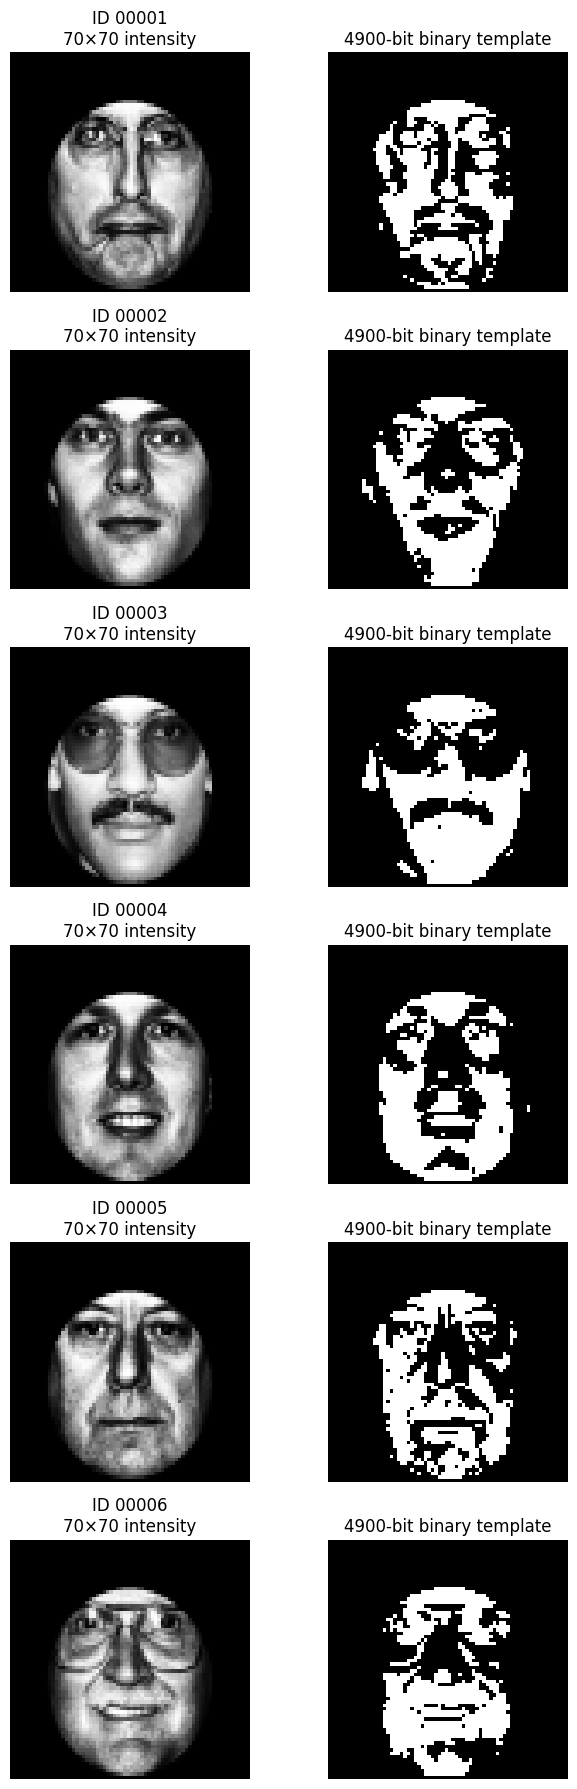

In [69]:
# ============================================================
# CELL 38 — VISUALIZE INTENSITY VS BINARY TEMPLATE
# ============================================================

N_SHOW = 6

fig, axes = plt.subplots(
    N_SHOW,
    2,
    figsize=(7, 3 * N_SHOW)
)

for row in range(N_SHOW):

    intensity = ENROLLMENT_FEATURES[
        row
    ].reshape(70, 70)

    binary = ENROLLMENT_BINARY[
        row
    ].reshape(70, 70)

    identity = enrollment_metadata_df.iloc[
        row
    ]["identity"]

    # Original 70x70 intensity representation
    axes[row, 0].imshow(
        intensity,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[row, 0].set_title(
        f"ID {identity}\n70×70 intensity"
    )

    axes[row, 0].axis("off")

    # Binary representation
    axes[row, 1].imshow(
        binary,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        "4900-bit binary template"
    )

    axes[row, 1].axis("off")


plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# CELL 39 — VERIFY ONE BINARY TEMPLATE
# ============================================================

idx = 0

template = ENROLLMENT_BINARY[idx]

identity = enrollment_metadata_df.iloc[
    idx
]["identity"]


print("=" * 80)
print("BINARY TEMPLATE VERIFICATION")
print("=" * 80)

print("Identity      :", identity)
print("Shape         :", template.shape)
print("Length        :", len(template))
print("dtype         :", template.dtype)

print(
    "Unique values :",
    np.unique(template)
)

print(
    "Number of 1s  :",
    int(template.sum())
)

print(
    "Number of 0s  :",
    int(4900 - template.sum())
)

print("\nFirst 100 bits:")
print(
    "".join(
        map(str, template[:100])
    )
)

assert len(template) == 4900

BINARY TEMPLATE VERIFICATION
Identity      : 00001
Shape         : (4900,)
Length        : 4900
dtype         : uint8
Unique values : [0 1]
Number of 1s  : 1046
Number of 0s  : 3854

First 100 bits:
0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


In [71]:
# ============================================================
# CELL 40 — SUCCESSFUL ENROLLMENT IDENTITY MAP
# ============================================================

successful_ids = set(
    enrollment_metadata_df[
        "identity"
    ].tolist()
)

protocol_success = [
    rec
    for rec in feret_protocol_records
    if rec["identity"] in successful_ids
]

print(
    "Usable enrolled identities:",
    len(protocol_success)
)

print(
    "With usable FB path:",
    sum(
        rec["second_path"] is not None
        for rec in protocol_success
    )
)

Usable enrolled identities: 993
With usable FB path: 992


In [72]:
# ============================================================
# CELL 41 — SELECT GENUINE QUERY IDENTITIES
# ============================================================

rng = np.random.default_rng(SEED)

# Identities must have a second FB image available
eligible_second = [
    rec
    for rec in protocol_success
    if rec["second_path"] is not None
]

if len(protocol_success) < 700:
    raise RuntimeError(
        "Need at least 700 successfully enrolled identities "
        "for disjoint 400 exact + 300 second-image queries."
    )

# Reproducibly shuffle identities
all_indices = rng.permutation(
    len(protocol_success)
)

exact_indices = all_indices[:400]
second_indices = all_indices[400:700]

exact_records = [
    protocol_success[i]
    for i in exact_indices
]

second_records = [
    protocol_success[i]
    for i in second_indices
]


print("=" * 80)
print("GENUINE QUERY SPLIT")
print("=" * 80)

print(
    "Exact identities  :",
    len(exact_records)
)

print(
    "Second identities :",
    len(second_records)
)

exact_ids = {
    r["identity"]
    for r in exact_records
}

second_ids = {
    r["identity"]
    for r in second_records
}

print(
    "Identity overlap  :",
    len(
        exact_ids.intersection(
            second_ids
        )
    )
)

GENUINE QUERY SPLIT
Exact identities  : 400
Second identities : 300
Identity overlap  : 0


In [73]:
# ============================================================
# CELL 42 — BUILD BALANCED FACES94 IMPOSTOR POOL
# ============================================================

faces94_pool = []

# Round-robin over image position so identities are distributed
max_images = max(
    rec["num_images"]
    for rec in faces94_records
)

for image_idx in range(max_images):

    for rec in faces94_records:

        if image_idx < len(rec["images"]):

            faces94_pool.append({
                "identity": rec["identity"],
                "group": rec["group"],
                "path": rec["images"][image_idx]
            })

            if len(faces94_pool) >= N_UNENROLLED:
                break

    if len(faces94_pool) >= N_UNENROLLED:
        break


if len(faces94_pool) < N_UNENROLLED:
    raise RuntimeError(
        "Not enough Faces94 images for requested impostor set."
    )

faces94_query_records = faces94_pool[
    :N_UNENROLLED
]


print("=" * 80)
print("FACES94 IMPOSTOR QUERY SET")
print("=" * 80)

print(
    "Images selected    :",
    len(faces94_query_records)
)

print(
    "Unique identities  :",
    len(
        set(
            r["identity"]
            for r in faces94_query_records
        )
    )
)

FACES94 IMPOSTOR QUERY SET
Images selected    : 300
Unique identities  : 153


In [74]:
# ============================================================
# CELL 43 — PREPROCESS ALL THREE QUERY TYPES
# ============================================================

query_vectors = []
query_metadata = []
query_failures = []


def add_query(
    path,
    identity,
    query_type,
    source,
    enrolled
):

    vector = preprocess_to_4900(
        path
    )

    if vector is None:

        query_failures.append({
            "identity": identity,
            "path": str(path),
            "query_type": query_type,
            "source": source
        })

        return False

    query_vectors.append(
        vector
    )

    query_metadata.append({
        "identity": identity,
        "filename": Path(path).name,
        "image_path": str(path),
        "query_type": query_type,
        "source": source,
        "enrolled_identity": int(enrolled)
    })

    return True


# ------------------------------------------------------------
# 1. EXACT ENROLLED
# ------------------------------------------------------------

print("Processing exact queries...")

for rec in tqdm(exact_records):

    add_query(
        rec["enrollment_path"],
        rec["identity"],
        "exact",
        "FERETD",
        True
    )


# ------------------------------------------------------------
# 2. SECOND IMAGE — SAME ENROLLED PERSON
# ------------------------------------------------------------

print("\nProcessing second-image queries...")

for rec in tqdm(second_records):

    add_query(
        rec["second_path"],
        rec["identity"],
        "second",
        "FERETD",
        True
    )


# ------------------------------------------------------------
# 3. NEVER ENROLLED — FACES94
# ------------------------------------------------------------

print("\nProcessing Faces94 impostor queries...")

for rec in tqdm(faces94_query_records):

    add_query(
        rec["path"],
        rec["identity"],
        "impostor",
        "Faces94",
        False
    )


QUERY_FEATURES = np.stack(
    query_vectors
).astype(np.float32)

query_metadata_df = pd.DataFrame(
    query_metadata
)


print("\n" + "=" * 80)
print("QUERY PREPROCESSING SUMMARY")
print("=" * 80)

print(
    "Successful queries :",
    QUERY_FEATURES.shape[0]
)

print(
    "Failed queries     :",
    len(query_failures)
)

print(
    "Matrix shape       :",
    QUERY_FEATURES.shape
)

print("\nSuccessful query categories:")

print(
    query_metadata_df[
        "query_type"
    ].value_counts()
)

Processing exact queries...


  0%|          | 0/400 [00:00<?, ?it/s]


Processing second-image queries...


  0%|          | 0/300 [00:00<?, ?it/s]


Processing Faces94 impostor queries...


  0%|          | 0/300 [00:00<?, ?it/s]


QUERY PREPROCESSING SUMMARY
Successful queries : 999
Failed queries     : 1
Matrix shape       : (999, 4900)

Successful query categories:
query_type
exact       400
second      300
impostor    299
Name: count, dtype: int64


In [75]:
# ============================================================
# CELL 44 — QUERY BINARIZATION
# ============================================================

QUERY_BINARY = (
    QUERY_FEATURES > MEAN_VECTOR
).astype(np.uint8)


print("=" * 80)
print("QUERY BINARY TEMPLATES")
print("=" * 80)

print(
    "Shape         :",
    QUERY_BINARY.shape
)

print(
    "dtype         :",
    QUERY_BINARY.dtype
)

print(
    "Unique values :",
    np.unique(QUERY_BINARY)
)

print(
    "Mean P(bit=1) :",
    f"{QUERY_BINARY.mean():.6f}"
)

assert QUERY_BINARY.shape[1] == 4900

QUERY BINARY TEMPLATES
Shape         : (999, 4900)
dtype         : uint8
Unique values : [0 1]
Mean P(bit=1) : 0.217012


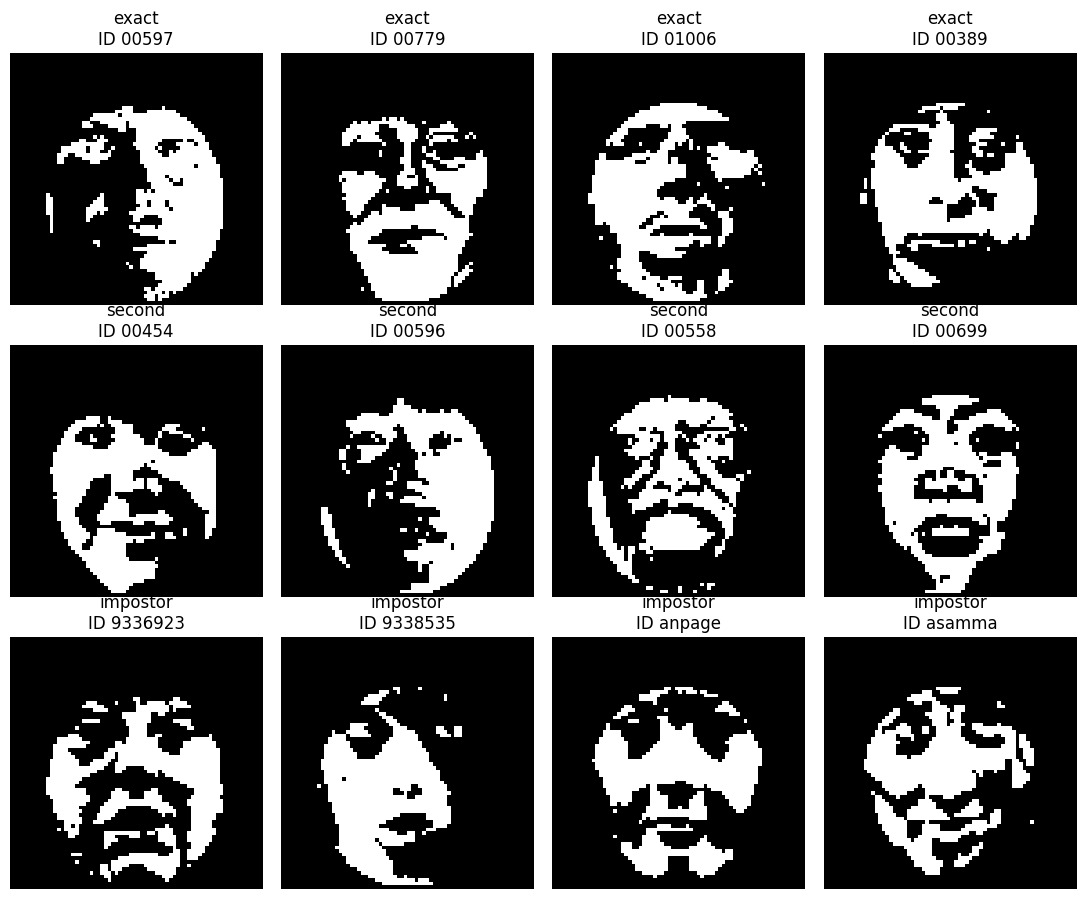

In [76]:
# ============================================================
# CELL 45 — QUERY CATEGORY VISUALIZATION
# ============================================================

categories = [
    "exact",
    "second",
    "impostor"
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(11, 9)
)

for row, category in enumerate(categories):

    indices = query_metadata_df.index[
        query_metadata_df["query_type"]
        == category
    ].tolist()

    for col, idx in enumerate(indices[:4]):

        binary = QUERY_BINARY[
            idx
        ].reshape(70, 70)

        identity = query_metadata_df.iloc[
            idx
        ]["identity"]

        axes[row, col].imshow(
            binary,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row, col].set_title(
            f"{category}\nID {identity}"
        )

        axes[row, col].axis("off")


plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# INSPECT FAILED QUERY
# ============================================================

print("=" * 80)
print("FAILED QUERY RECORDS")
print("=" * 80)

for failure in query_failures:
    print(failure)

FAILED QUERY RECORDS
{'identity': 'djmart', 'path': '/kaggle/input/datasets/pyarapikachu/faces94/faces94/male/djmart/djmart.1.jpg', 'query_type': 'impostor', 'source': 'Faces94'}


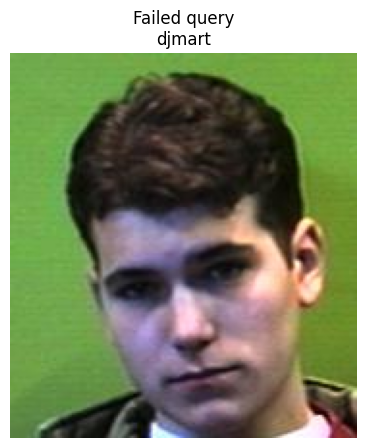

In [78]:
# ============================================================
# VISUALIZE FAILED IMAGE
# ============================================================

failed_path = query_failures[0]["path"]

img = cv2.imread(failed_path)

if img is not None:
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(
        f"Failed query\n"
        f"{query_failures[0]['identity']}"
    )
    plt.axis("off")
    plt.show()
else:
    print("Image itself could not be loaded.")

In [80]:
# ============================================================
# FIX — BUILD COMPLETE FACES94 CANDIDATE POOL
# ============================================================

faces94_full_pool = []

# Round-robin by image index so we still distribute
# candidates across identities rather than exhausting
# one identity at a time.
max_images = max(
    rec["num_images"]
    for rec in faces94_records
)

for image_idx in range(max_images):

    for rec in faces94_records:

        if image_idx < len(rec["images"]):

            faces94_full_pool.append({
                "identity": rec["identity"],
                "group": rec["group"],
                "path": rec["images"][image_idx]
            })


print("=" * 80)
print("COMPLETE FACES94 CANDIDATE POOL")
print("=" * 80)

print(
    "Total candidate images :",
    len(faces94_full_pool)
)

print(
    "Unique identities      :",
    len(
        set(
            r["identity"]
            for r in faces94_full_pool
        )
    )
)

COMPLETE FACES94 CANDIDATE POOL
Total candidate images : 3059
Unique identities      : 153


In [81]:
# ============================================================
# REPLACE FAILED IMPOSTOR QUERY
# ============================================================

current_impostor_paths = set(
    query_metadata_df.loc[
        query_metadata_df["query_type"] == "impostor",
        "image_path"
    ].tolist()
)

needed = (
    N_UNENROLLED
    - int(
        (
            query_metadata_df["query_type"]
            == "impostor"
        ).sum()
    )
)

print("Replacement impostors needed:", needed)

replacement_records = []


for rec in faces94_full_pool:

    if len(replacement_records) >= needed:
        break

    candidate_path = str(
        rec["path"]
    )

    # ------------------------------------------
    # Do not reuse an already successful query
    # ------------------------------------------
    if candidate_path in current_impostor_paths:
        continue

    # ------------------------------------------
    # Try preprocessing
    # ------------------------------------------
    vector = preprocess_to_4900(
        rec["path"]
    )

    if vector is None:
        continue

    replacement_records.append({
        "identity": rec["identity"],
        "group": rec["group"],
        "path": rec["path"],
        "vector": vector
    })


if len(replacement_records) < needed:

    raise RuntimeError(
        f"Needed {needed} replacement(s), "
        f"but only found {len(replacement_records)}."
    )


# ============================================================
# APPEND SUCCESSFUL REPLACEMENTS
# ============================================================

for rec in replacement_records:

    query_vectors.append(
        rec["vector"]
    )

    query_metadata.append({
        "identity": rec["identity"],
        "filename": Path(
            rec["path"]
        ).name,
        "image_path": str(
            rec["path"]
        ),
        "query_type": "impostor",
        "source": "Faces94",
        "enrolled_identity": 0
    })


# ============================================================
# REBUILD QUERY MATRICES
# ============================================================

QUERY_FEATURES = np.stack(
    query_vectors
).astype(np.float32)

query_metadata_df = pd.DataFrame(
    query_metadata
)

QUERY_BINARY = (
    QUERY_FEATURES > MEAN_VECTOR
).astype(np.uint8)


print("\n" + "=" * 80)
print("FINAL QUERY SET")
print("=" * 80)

print(
    query_metadata_df[
        "query_type"
    ].value_counts()
)

print(
    "\nTotal queries :",
    len(query_metadata_df)
)

print(
    "Matrix shape  :",
    QUERY_BINARY.shape
)

print(
    "Unique bits   :",
    np.unique(QUERY_BINARY)
)

Replacement impostors needed: 1

FINAL QUERY SET
query_type
exact       400
second      300
impostor    300
Name: count, dtype: int64

Total queries : 1000
Matrix shape  : (1000, 4900)
Unique bits   : [0 1]


In [82]:
# ============================================================
# CELL 46 — VERIFY EXACT QUERIES MATCH ENROLLMENT TEMPLATES
# ============================================================

# Map enrollment identity -> binary template row
enrollment_index_by_id = {
    row["identity"]: idx
    for idx, row in enrollment_metadata_df.iterrows()
}

exact_rows = query_metadata_df[
    query_metadata_df["query_type"] == "exact"
].reset_index()

n_exact_identical = 0
exact_hamming = []

for _, row in exact_rows.iterrows():

    q_idx = row["index"]
    identity = row["identity"]

    e_idx = enrollment_index_by_id[identity]

    enrollment_template = ENROLLMENT_BINARY[e_idx]
    query_template = QUERY_BINARY[q_idx]

    hd = np.sum(
        enrollment_template != query_template
    )

    exact_hamming.append(hd)

    if hd == 0:
        n_exact_identical += 1


print("=" * 80)
print("EXACT QUERY SANITY CHECK")
print("=" * 80)

print(
    "Exact queries tested     :",
    len(exact_rows)
)

print(
    "Bit-for-bit identical    :",
    n_exact_identical
)

print(
    "Minimum Hamming distance :",
    np.min(exact_hamming)
)

print(
    "Maximum Hamming distance :",
    np.max(exact_hamming)
)

print(
    "Mean Hamming distance    :",
    np.mean(exact_hamming)
)

assert n_exact_identical == len(exact_rows)
assert max(exact_hamming) == 0

EXACT QUERY SANITY CHECK
Exact queries tested     : 400
Bit-for-bit identical    : 400
Minimum Hamming distance : 0
Maximum Hamming distance : 0
Mean Hamming distance    : 0.0


In [83]:
# ============================================================
# CELL 47 — SECOND-IMAGE HAMMING DISTANCE CHECK
# ============================================================

second_rows = query_metadata_df[
    query_metadata_df["query_type"] == "second"
].reset_index()

second_hd = []

for _, row in second_rows.iterrows():

    q_idx = row["index"]
    identity = row["identity"]

    e_idx = enrollment_index_by_id[identity]

    enrollment_template = ENROLLMENT_BINARY[e_idx]
    query_template = QUERY_BINARY[q_idx]

    hd = np.sum(
        enrollment_template != query_template
    )

    second_hd.append(hd)


second_hd = np.array(second_hd)

print("=" * 80)
print("SECOND-IMAGE QUERY HAMMING DISTANCE")
print("=" * 80)

print(
    "Queries                  :",
    len(second_hd)
)

print(
    "Mean HD                  :",
    f"{second_hd.mean():.2f} bits"
)

print(
    "Median HD                :",
    f"{np.median(second_hd):.2f} bits"
)

print(
    "Minimum HD               :",
    int(second_hd.min())
)

print(
    "Maximum HD               :",
    int(second_hd.max())
)

print(
    "Mean normalized HD       :",
    f"{(second_hd / 4900).mean():.4f}"
)

print(
    "Median normalized HD     :",
    f"{np.median(second_hd / 4900):.4f}"
)

SECOND-IMAGE QUERY HAMMING DISTANCE
Queries                  : 300
Mean HD                  : 402.40 bits
Median HD                : 388.50 bits
Minimum HD               : 54
Maximum HD               : 951
Mean normalized HD       : 0.0821
Median normalized HD     : 0.0793


In [84]:
# ============================================================
# CELL 48 — IMPOSTOR NEAREST-ENROLLMENT HAMMING CHECK
# ============================================================

impostor_indices = query_metadata_df.index[
    query_metadata_df["query_type"] == "impostor"
].tolist()

impostor_min_hd = []

for q_idx in tqdm(impostor_indices):

    q = QUERY_BINARY[q_idx]

    distances = np.sum(
        ENROLLMENT_BINARY != q,
        axis=1
    )

    impostor_min_hd.append(
        distances.min()
    )


impostor_min_hd = np.array(
    impostor_min_hd
)

print("=" * 80)
print("IMPOSTOR → NEAREST ENROLLMENT HAMMING DISTANCE")
print("=" * 80)

print(
    "Impostor queries          :",
    len(impostor_min_hd)
)

print(
    "Mean nearest HD           :",
    f"{impostor_min_hd.mean():.2f}"
)

print(
    "Median nearest HD         :",
    f"{np.median(impostor_min_hd):.2f}"
)

print(
    "Minimum nearest HD        :",
    int(impostor_min_hd.min())
)

print(
    "Maximum nearest HD        :",
    int(impostor_min_hd.max())
)

print(
    "Mean normalized nearestHD :",
    f"{(impostor_min_hd / 4900).mean():.4f}"
)

  0%|          | 0/300 [00:00<?, ?it/s]

IMPOSTOR → NEAREST ENROLLMENT HAMMING DISTANCE
Impostor queries          : 300
Mean nearest HD           : 564.33
Median nearest HD         : 566.00
Minimum nearest HD        : 304
Maximum nearest HD        : 768
Mean normalized nearestHD : 0.1152


In [86]:
# ============================================================
# CELL 50 — FINAL STRUCTURAL VALIDATION
# ============================================================

print("=" * 80)
print("FINAL TEMPLATE VALIDATION")
print("=" * 80)

print(
    "Enrollment shape :",
    ENROLLMENT_BINARY.shape
)

print(
    "Query shape      :",
    QUERY_BINARY.shape
)

print(
    "Mean shape       :",
    MEAN_VECTOR.shape
)

print(
    "Enrollment dtype :",
    ENROLLMENT_BINARY.dtype
)

print(
    "Query dtype      :",
    QUERY_BINARY.dtype
)

print(
    "Enrollment bits  :",
    np.unique(ENROLLMENT_BINARY)
)

print(
    "Query bits       :",
    np.unique(QUERY_BINARY)
)


assert ENROLLMENT_BINARY.ndim == 2
assert QUERY_BINARY.ndim == 2

assert ENROLLMENT_BINARY.shape[1] == 4900
assert QUERY_BINARY.shape[1] == 4900

assert MEAN_VECTOR.shape == (4900,)

assert set(
    np.unique(ENROLLMENT_BINARY)
).issubset({0, 1})

assert set(
    np.unique(QUERY_BINARY)
).issubset({0, 1})

assert len(query_metadata_df) == 1000

assert (
    query_metadata_df["query_type"]
    .value_counts()
    .to_dict()
    ==
    {
        "exact": 400,
        "second": 300,
        "impostor": 300
    }
)

print("\n✓ All structural checks passed.")

FINAL TEMPLATE VALIDATION
Enrollment shape : (993, 4900)
Query shape      : (1000, 4900)
Mean shape       : (4900,)
Enrollment dtype : uint8
Query dtype      : uint8
Enrollment bits  : [0 1]
Query bits       : [0 1]

✓ All structural checks passed.


BINARY TEMPLATE SEPARATION

GENUINE — same identity
Mean   : 402.40
Median : 388.50

IMPOSTOR — random enrollment
Mean   : 1028.34
Median : 1032.00


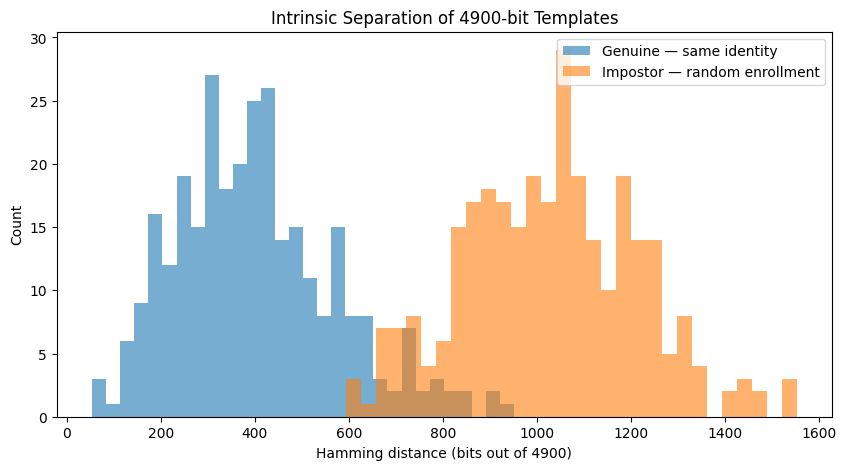

In [87]:
# ============================================================
# BETTER REPRESENTATION-SEPARATION DIAGNOSTIC
# ============================================================

rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Genuine distances:
# second image vs its own enrollment
# ------------------------------------------------------------

genuine_hd = []

for _, row in second_rows.iterrows():

    q_idx = row["index"]
    identity = row["identity"]

    e_idx = enrollment_index_by_id[identity]

    hd = np.sum(
        QUERY_BINARY[q_idx]
        != ENROLLMENT_BINARY[e_idx]
    )

    genuine_hd.append(hd)

genuine_hd = np.array(genuine_hd)


# ------------------------------------------------------------
# Random impostor distances:
# Faces94 query vs one random FERETD enrollment
# ------------------------------------------------------------

random_impostor_hd = []

for q_idx in impostor_indices:

    e_idx = rng.integers(
        0,
        len(ENROLLMENT_BINARY)
    )

    hd = np.sum(
        QUERY_BINARY[q_idx]
        != ENROLLMENT_BINARY[e_idx]
    )

    random_impostor_hd.append(hd)

random_impostor_hd = np.array(
    random_impostor_hd
)


# ------------------------------------------------------------
# Print statistics
# ------------------------------------------------------------

print("=" * 80)
print("BINARY TEMPLATE SEPARATION")
print("=" * 80)

print("\nGENUINE — same identity")
print(
    "Mean   :",
    f"{genuine_hd.mean():.2f}"
)
print(
    "Median :",
    f"{np.median(genuine_hd):.2f}"
)

print("\nIMPOSTOR — random enrollment")
print(
    "Mean   :",
    f"{random_impostor_hd.mean():.2f}"
)
print(
    "Median :",
    f"{np.median(random_impostor_hd):.2f}"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    genuine_hd,
    bins=30,
    alpha=0.6,
    label="Genuine — same identity"
)

plt.hist(
    random_impostor_hd,
    bins=30,
    alpha=0.6,
    label="Impostor — random enrollment"
)

plt.xlabel(
    "Hamming distance (bits out of 4900)"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Intrinsic Separation of 4900-bit Templates"
)

plt.legend()

plt.show()

In [88]:
# ============================================================
# FINAL EXPORT — SAVE + ZIP EVERYTHING FOR DOWNLOAD
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json
import zipfile
import os

EXPORT_DIR = Path("/kaggle/working/FERETD_HBF_preprocessed")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ENROLL_DIR = EXPORT_DIR / "enrollment"
QUERY_DIR  = EXPORT_DIR / "query"
QUANT_DIR  = EXPORT_DIR / "quantization"
META_DIR   = EXPORT_DIR / "metadata"

for d in [ENROLL_DIR, QUERY_DIR, QUANT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# SAVE BINARY TEMPLATES
# ------------------------------------------------------------
np.save(
    ENROLL_DIR / "enrollment_templates_4900bit.npy",
    ENROLLMENT_BINARY.astype(np.uint8)
)

np.save(
    QUERY_DIR / "query_templates_4900bit.npy",
    QUERY_BINARY.astype(np.uint8)
)

# ------------------------------------------------------------
# SAVE PRE-BINARY FEATURES
# ------------------------------------------------------------
np.save(
    ENROLL_DIR / "enrollment_features_4900.npy",
    ENROLLMENT_FEATURES.astype(np.float32)
)

np.save(
    QUERY_DIR / "query_features_4900.npy",
    QUERY_FEATURES.astype(np.float32)
)

# ------------------------------------------------------------
# SAVE FROZEN MEAN VECTOR
# ------------------------------------------------------------
np.save(
    QUANT_DIR / "mean_vector_4900.npy",
    MEAN_VECTOR.astype(np.float32)
)

# ------------------------------------------------------------
# SAVE METADATA
# ------------------------------------------------------------
enrollment_metadata_df.to_csv(
    META_DIR / "enrollment_metadata.csv",
    index=False
)

query_metadata_df.to_csv(
    META_DIR / "query_metadata.csv",
    index=False
)

# ------------------------------------------------------------
# PREPROCESSING INFO
# ------------------------------------------------------------
info = {
    "template_height": 70,
    "template_width": 70,
    "template_bits": 4900,
    "enrollment_count": int(ENROLLMENT_BINARY.shape[0]),
    "query_count": int(QUERY_BINARY.shape[0]),
    "query_exact": int(
        (query_metadata_df["query_type"] == "exact").sum()
    ),
    "query_second": int(
        (query_metadata_df["query_type"] == "second").sum()
    ),
    "query_impostor": int(
        (query_metadata_df["query_type"] == "impostor").sum()
    ),
    "enrollment_source": "FERETD FA",
    "second_query_source": "FERETD FB",
    "impostor_source": "Faces94",
    "quantization": "per-feature threshold using frozen FERETD enrollment mean"
}

with open(
    META_DIR / "preprocessing_info.json",
    "w"
) as f:
    json.dump(info, f, indent=4)

# ------------------------------------------------------------
# VERIFY BEFORE ZIP
# ------------------------------------------------------------
assert ENROLLMENT_BINARY.shape[1] == 4900
assert QUERY_BINARY.shape[1] == 4900
assert QUERY_BINARY.shape[0] == 1000

assert set(np.unique(ENROLLMENT_BINARY)).issubset({0, 1})
assert set(np.unique(QUERY_BINARY)).issubset({0, 1})

# ------------------------------------------------------------
# CREATE ZIP
# ------------------------------------------------------------
ZIP_PATH = Path(
    "/kaggle/working/FERETD_HBF_preprocessed_4900bit.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for file_path in EXPORT_DIR.rglob("*"):

        if file_path.is_file():

            arcname = file_path.relative_to(EXPORT_DIR)

            zf.write(
                file_path,
                arcname=str(arcname)
            )

# ------------------------------------------------------------
# VERIFY ZIP CONTENTS
# ------------------------------------------------------------
print("=" * 80)
print("FINAL EXPORT COMPLETE")
print("=" * 80)

print("Enrollment shape :", ENROLLMENT_BINARY.shape)
print("Query shape      :", QUERY_BINARY.shape)
print("Mean vector      :", MEAN_VECTOR.shape)

print("\nQuery composition:")
print(
    query_metadata_df["query_type"].value_counts()
)

print("\nZIP path:")
print(ZIP_PATH)

print(
    f"\nZIP size: "
    f"{ZIP_PATH.stat().st_size / (1024**2):.2f} MB"
)

print("\nZIP contents:")
print("-" * 80)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for name in zf.namelist():
        print(name)

print("\n✓ ZIP successfully created and verified.")

FINAL EXPORT COMPLETE
Enrollment shape : (993, 4900)
Query shape      : (1000, 4900)
Mean vector      : (4900,)

Query composition:
query_type
exact       400
second      300
impostor    300
Name: count, dtype: int64

ZIP path:
/kaggle/working/FERETD_HBF_preprocessed_4900bit.zip

ZIP size: 6.99 MB

ZIP contents:
--------------------------------------------------------------------------------
metadata/enrollment_metadata.csv
metadata/preprocessing_info.json
metadata/query_metadata.csv
enrollment/enrollment_templates_4900bit.npy
enrollment/enrollment_features_4900.npy
query/query_templates_4900bit.npy
query/query_features_4900.npy
quantization/mean_vector_4900.npy

✓ ZIP successfully created and verified.
